# Combined Model Chromatin Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.DG1Analysis import DG1Analysis

output_directory = 'output/prototype_pipeline_subset'
dg1_analysis = DG1Analysis(output_directory)


Loading configs from replication runs:  output/prototype_pipeline_subset/single_replication/
Shifting mu0, gamma1, and gamma2, for alpha...


# Analysis of chromatin deconvolution

1. Start with sanity checks, show that we are able to load any of the deconvolution windows

In [3]:
dg1_analysis.load_chromatin_measures()

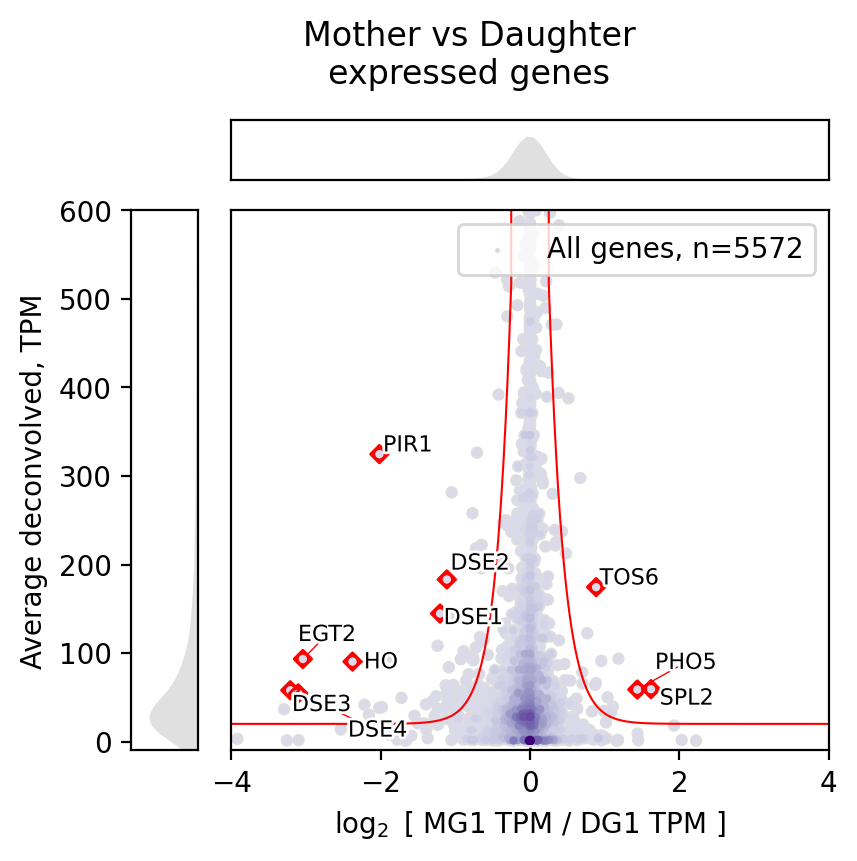

In [679]:
from pipeline.expression_analysis import ExpressionAnalysis
analysis = ExpressionAnalysis(output_directory)
analysis.plot_volcano_cg1_dg1(genes_callout=['DSE1', 'DSE2', 'DSE3', 'DSE4', 'PHO5',
                                            'HO', 'SPL2', 'PIR1', 'EGT2', 'TOS6'])


In [6]:
from src.geneset import get_deconvolved_geneset
genes = get_deconvolved_geneset()


In [7]:
dg1_cg1_sm_prom_gene_data = analysis.cg1_dg1_data.sort_values('max_ratio').join(genes[['gene']])

In [8]:
dg1_analysis.define_subsets(analysis)

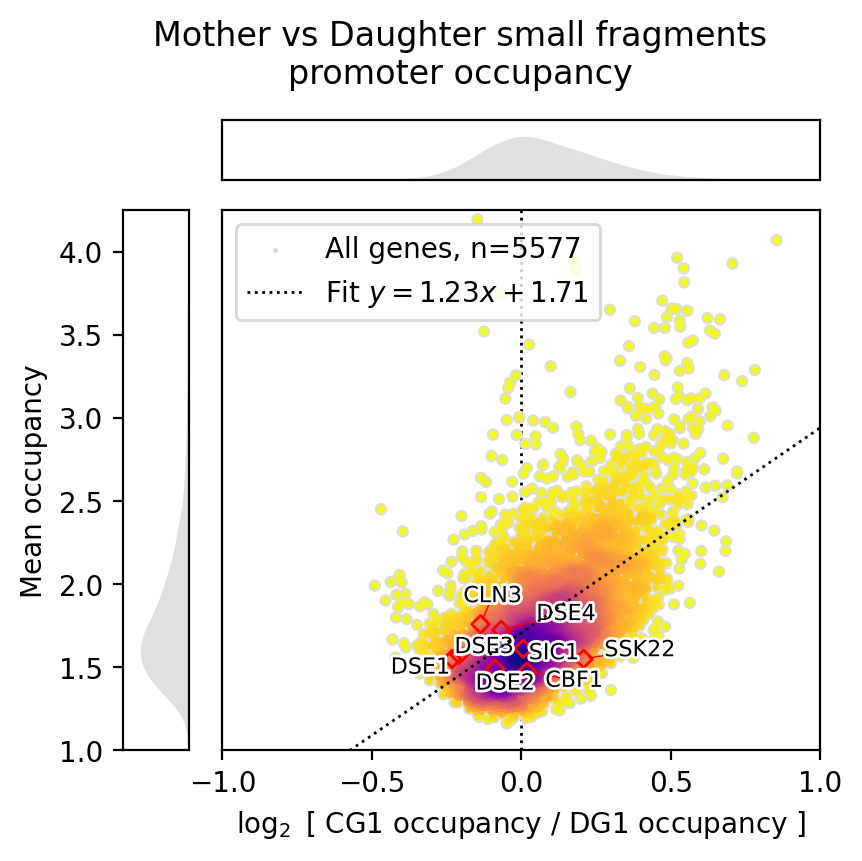

In [9]:
dg1_analysis.plot_dg1_vs_cg1()

In [ ]:
# dg1_analysis.plot_subset_dg1_tx()
# dg1_analysis.plot_subset_cg1_tx()

In [10]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genome_analysis = GenomeDeconvolutionAnalysis(outdir=
    f"{output_directory}/chromatin_deconvolution/deconvolution_data")

In [12]:
dg1_cg1_sm_prom_gene_data[dg1_cg1_sm_prom_gene_data.average_TPM > 70].head(3)

,average_TPM,max_ratio,gene
YNL327W,93.292382,-3.035351,EGT2
YDL227C,90.354081,-2.379897,HO
YKL164C,324.682728,-2.015116,PIR1


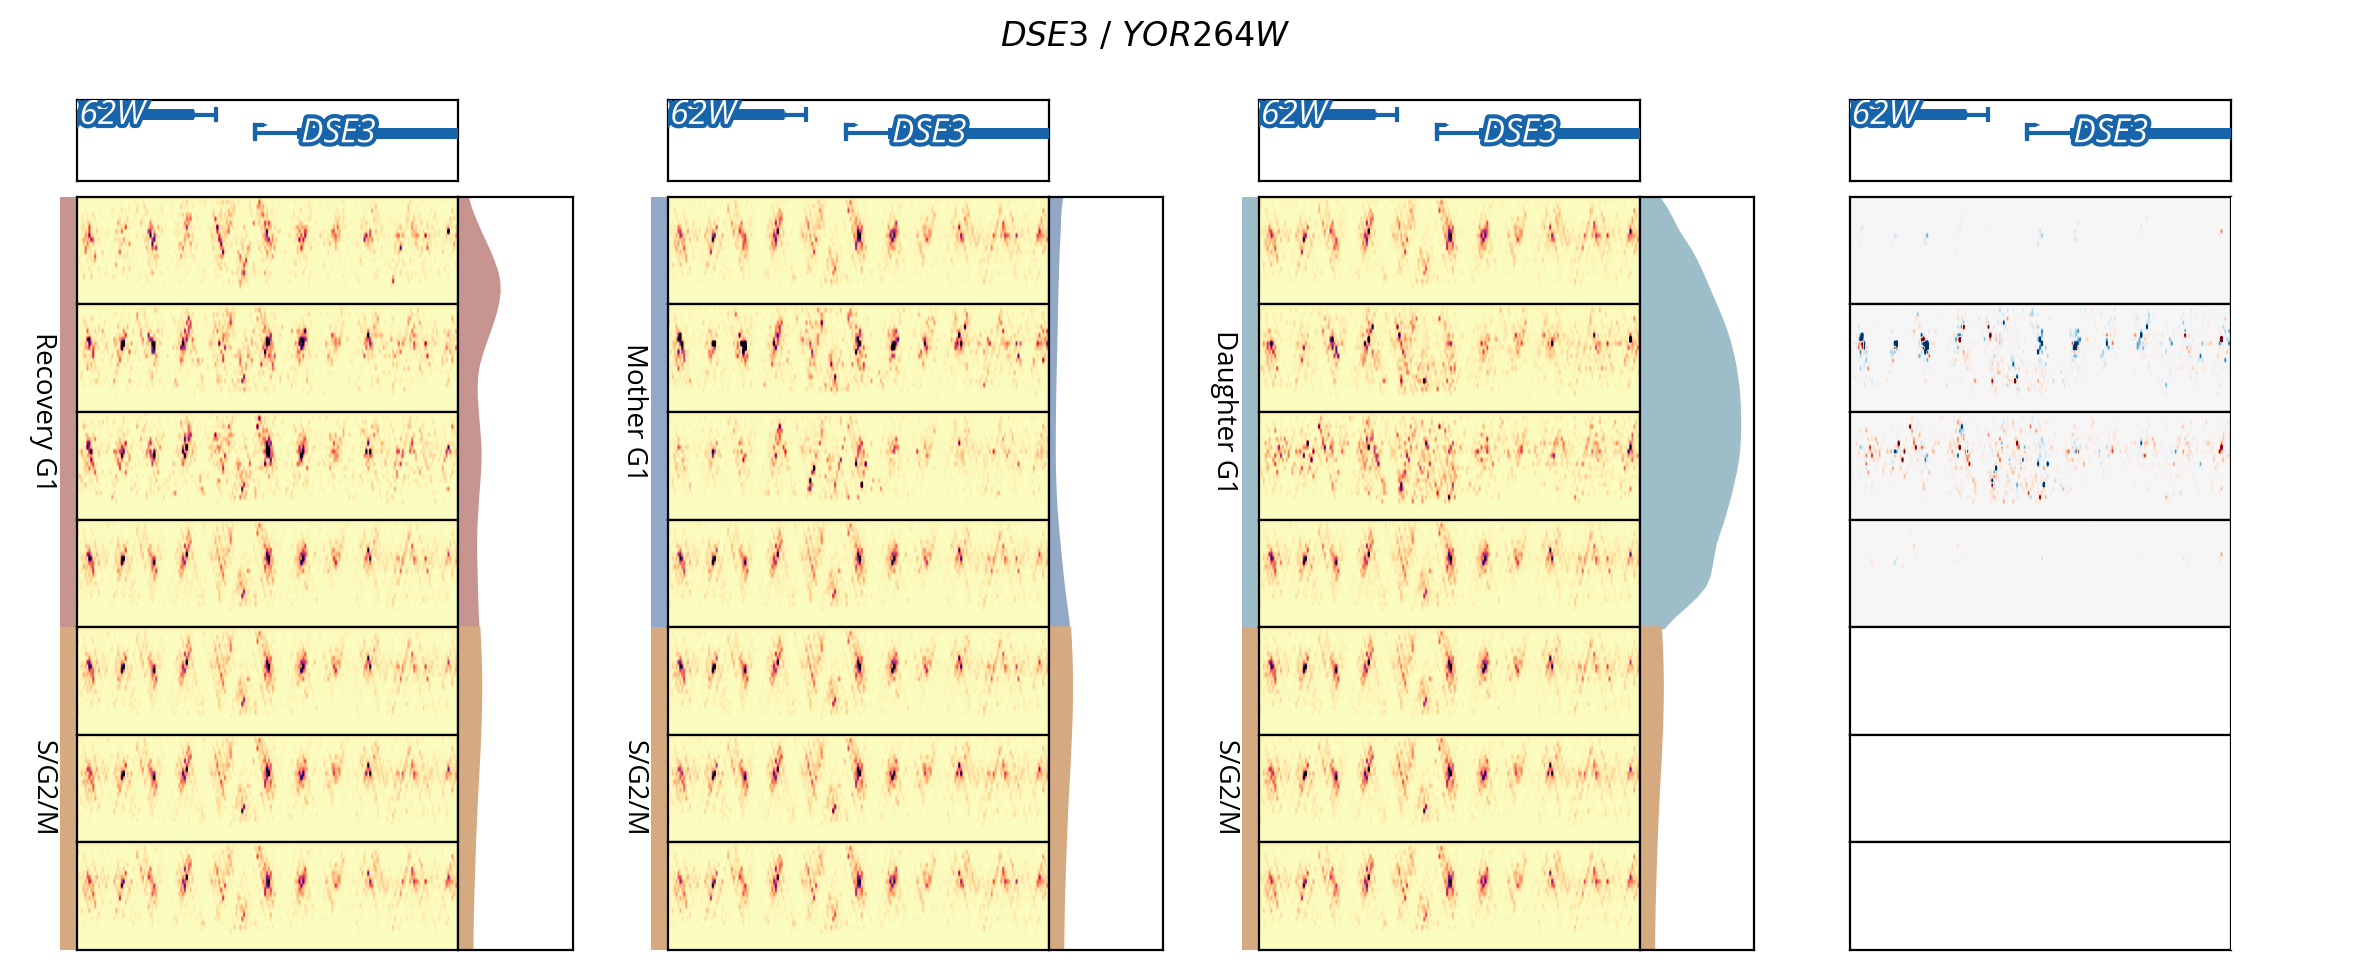

In [14]:
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs()

fig = genome_analysis.plot_gene('DSE3', config1, analysis)

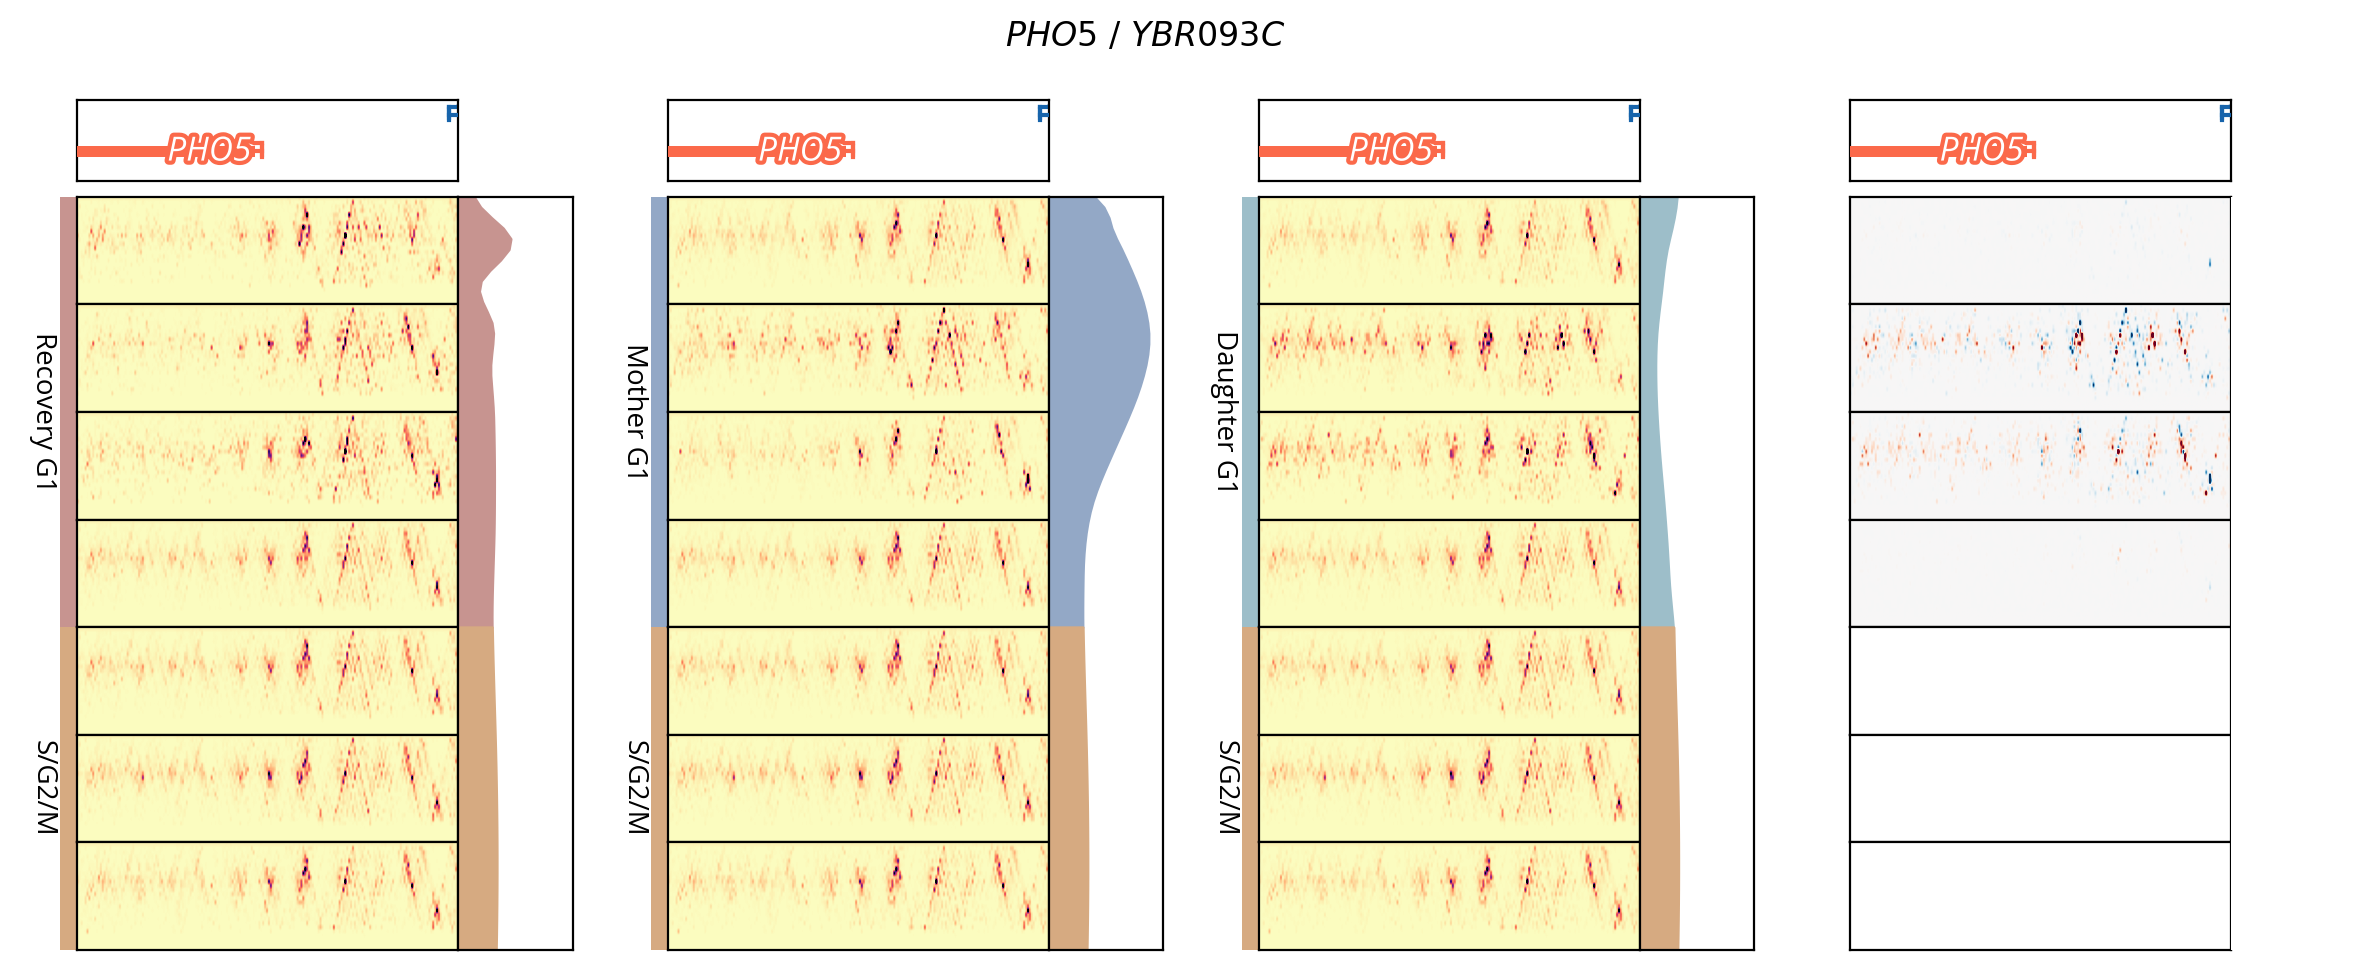

In [18]:
fig = genome_analysis.plot_gene('PHO5', config1, analysis)

In [339]:
unchanging_orfs, mg1_only, mg1_and_dg1, dg1_only, postg1_only = \
    analysis.retrieve_mg1_dg1_specific_genes(config1, proportion_threshold=0.1)


Using a threshold of 1.1
  429 post G1 expressed genes
  93 Mother G1 specific genes
  373 Daughter G1 specific genes
  90 Mother and Daughter expressed genes
  4587 All others
  Total:  5572


In [340]:
dg1_analysis.compute_g1_expression_sm_correlations(expressions_F, config1)

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


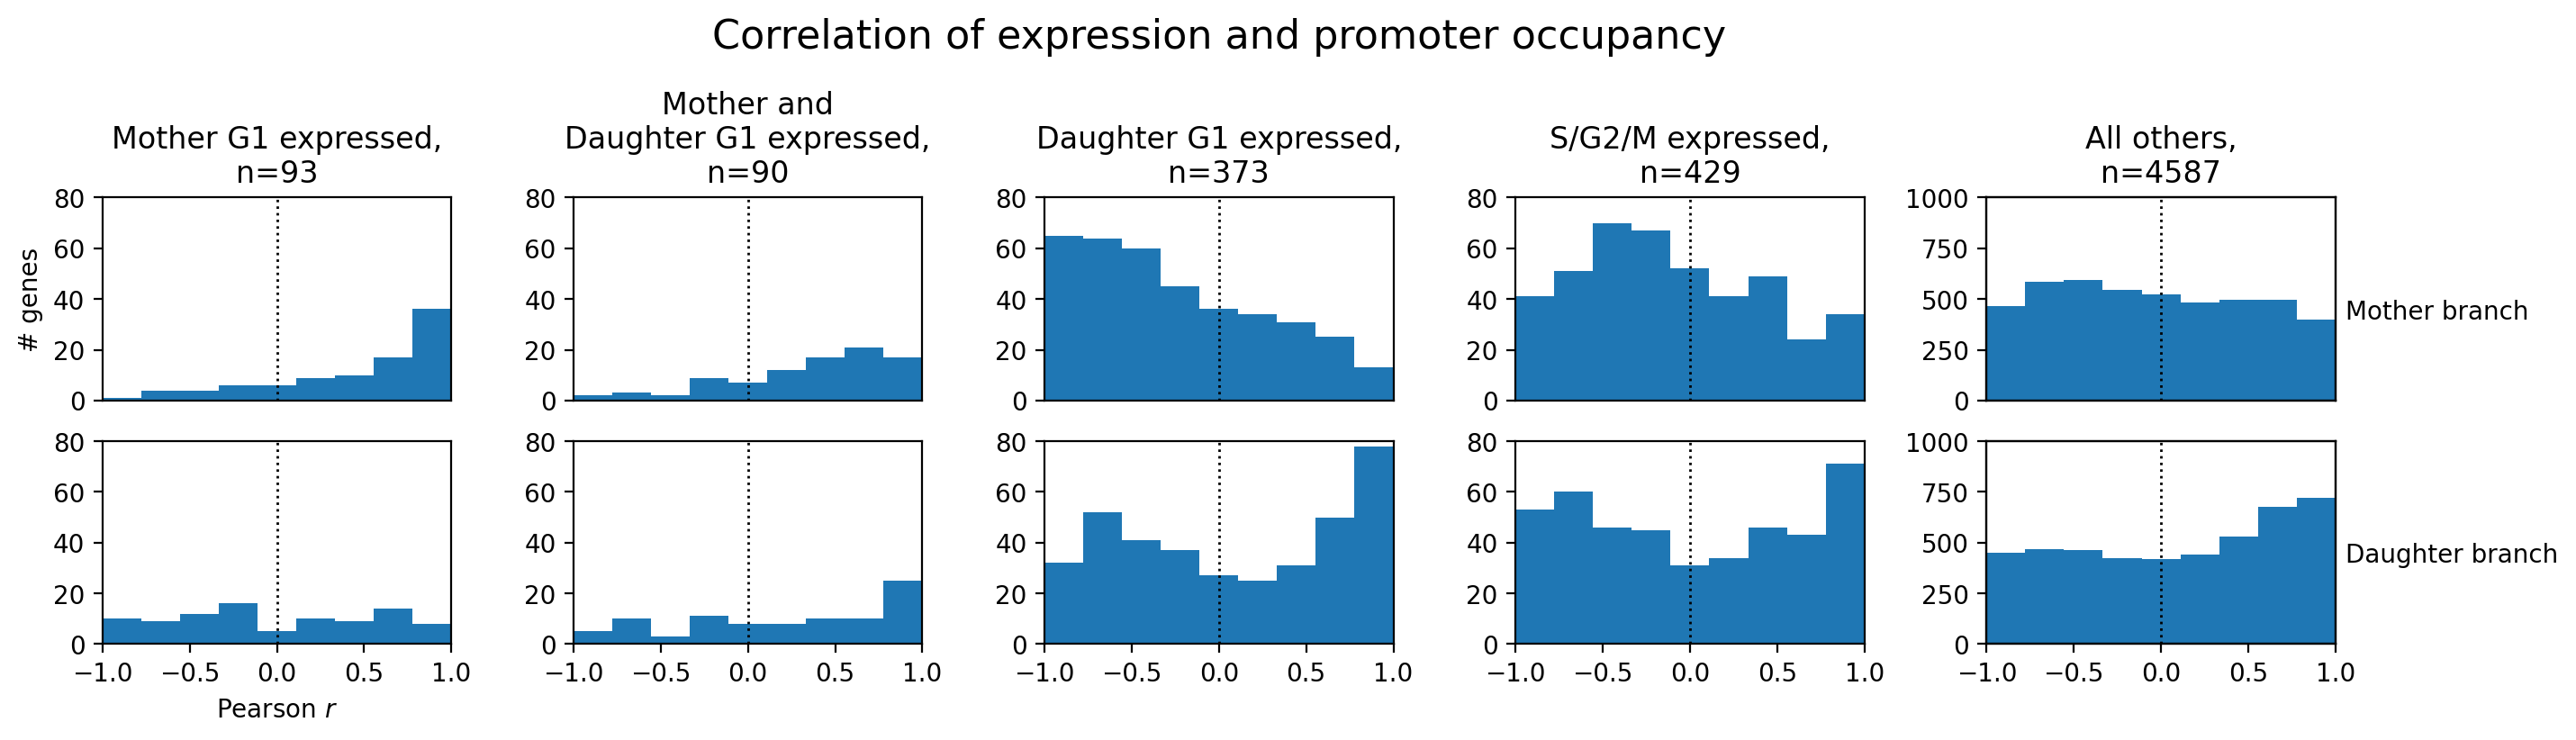

In [341]:
dg1_analysis.plot_tx_sm_correlation_histograms(mg1_only, mg1_and_dg1, dg1_only,
    postg1_only, unchanging_orfs)

Text(0.5, 1.0, 'Bottom vs Top Promoter Transcription Correlation,\n Daughter G1 expressed genes, n=373')

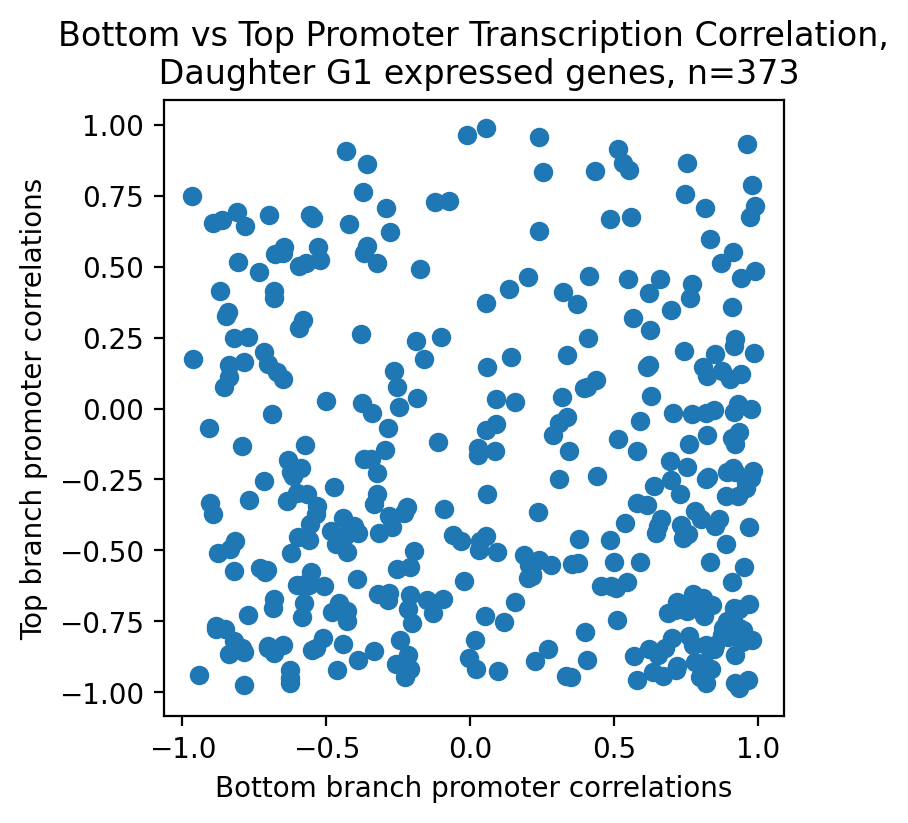

In [352]:
plt.figure(figsize=(4, 4))
plt.scatter(dg1_analysis.small_tx_bottom_correlations.loc[dg1_only].correlation,
            dg1_analysis.small_tx_top_correlations.loc[dg1_only].correlation)
plt.xlabel("Bottom branch promoter correlations")
plt.ylabel("Top branch promoter correlations")
# the removal of a TF on the mother branch (negative/anti correlation).
plt.title("Bottom vs Top Promoter Transcription Correlation,\n Daughter G1 expressed genes,"
         f" n={len(dg1_only)}")

(<Figure size 2000x600 with 10 Axes>,
 array([[<Axes: title={'center': 'MG1 only\n(n=93)'}, ylabel='Normalized Expression (z-score)'>,
         <Axes: title={'center': 'DG1 only\n(n=373)'}, ylabel='Normalized Expression (z-score)'>,
         <Axes: title={'center': 'MG1 and DG1\n(n=90)'}, ylabel='Normalized Expression (z-score)'>,
         <Axes: title={'center': 'Post G1\n(n=429)'}, ylabel='Normalized Expression (z-score)'>,
         <Axes: title={'center': 'Uncategorized\n(n=4587)'}, ylabel='Normalized Expression (z-score)'>],
        [<Axes: xlabel='Time', ylabel='Normalized Expression (z-score)'>,
         <Axes: xlabel='Time', ylabel='Normalized Expression (z-score)'>,
         <Axes: xlabel='Time', ylabel='Normalized Expression (z-score)'>,
         <Axes: xlabel='Time', ylabel='Normalized Expression (z-score)'>,
         <Axes: xlabel='Time', ylabel='Normalized Expression (z-score)'>]],
       dtype=object))

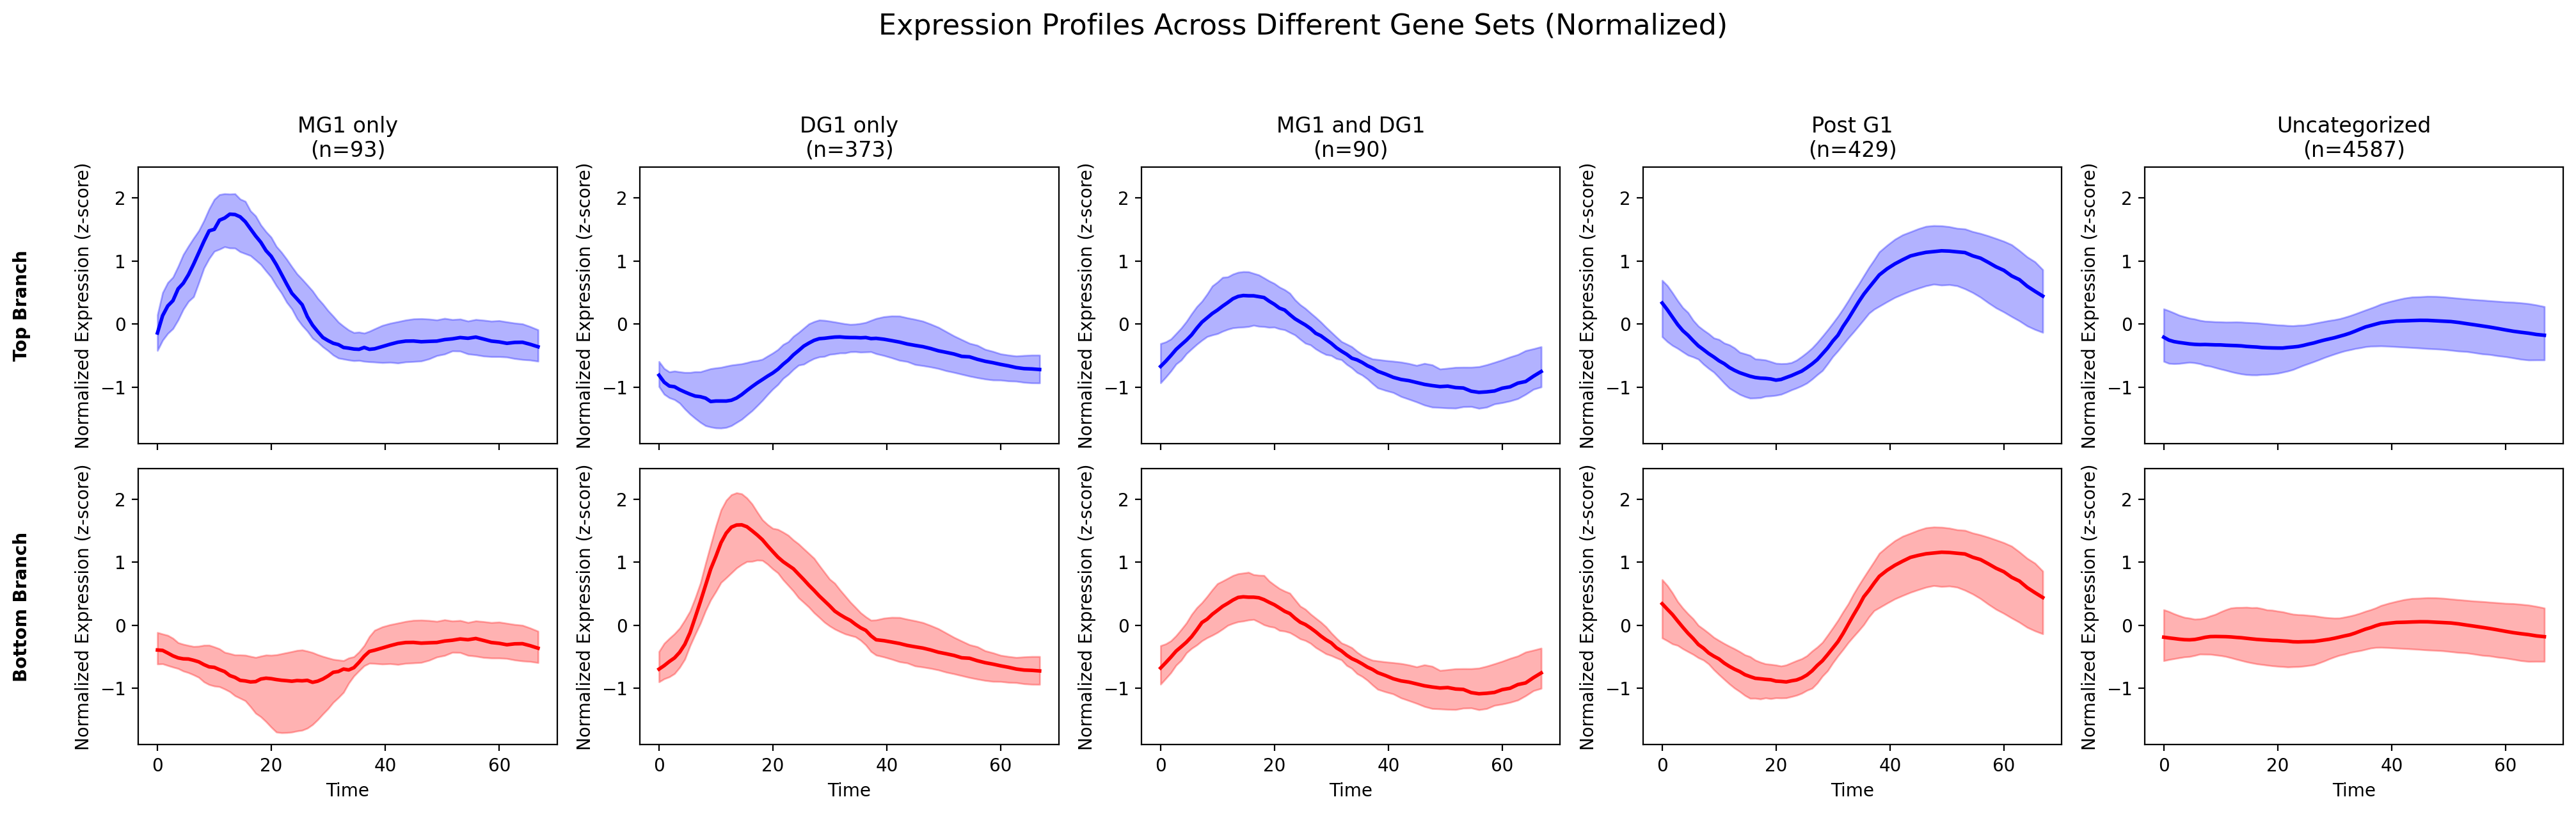

In [521]:
from pipeline.expression_analysis import plot_expression_quantiles

# Normalized plot
plot_expression_quantiles(config1, expressions_F, gene_subsets, t_indices,
                                        b_indices, normalize=True)


In [445]:
from src.chromatin_expression_optimal_shift import ExpressionCorrelationAnalyzer
from src.timer import Timer

timer = Timer()

# Initialize analyzer
analyzer = ExpressionCorrelationAnalyzer(expressions_df, small_occupancies, 
    max_shift=len(t_indices)//2)

# Analyze both branches
results = analyzer.analyze_branches(config1)
timer.print_time()


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


00:05:48.821


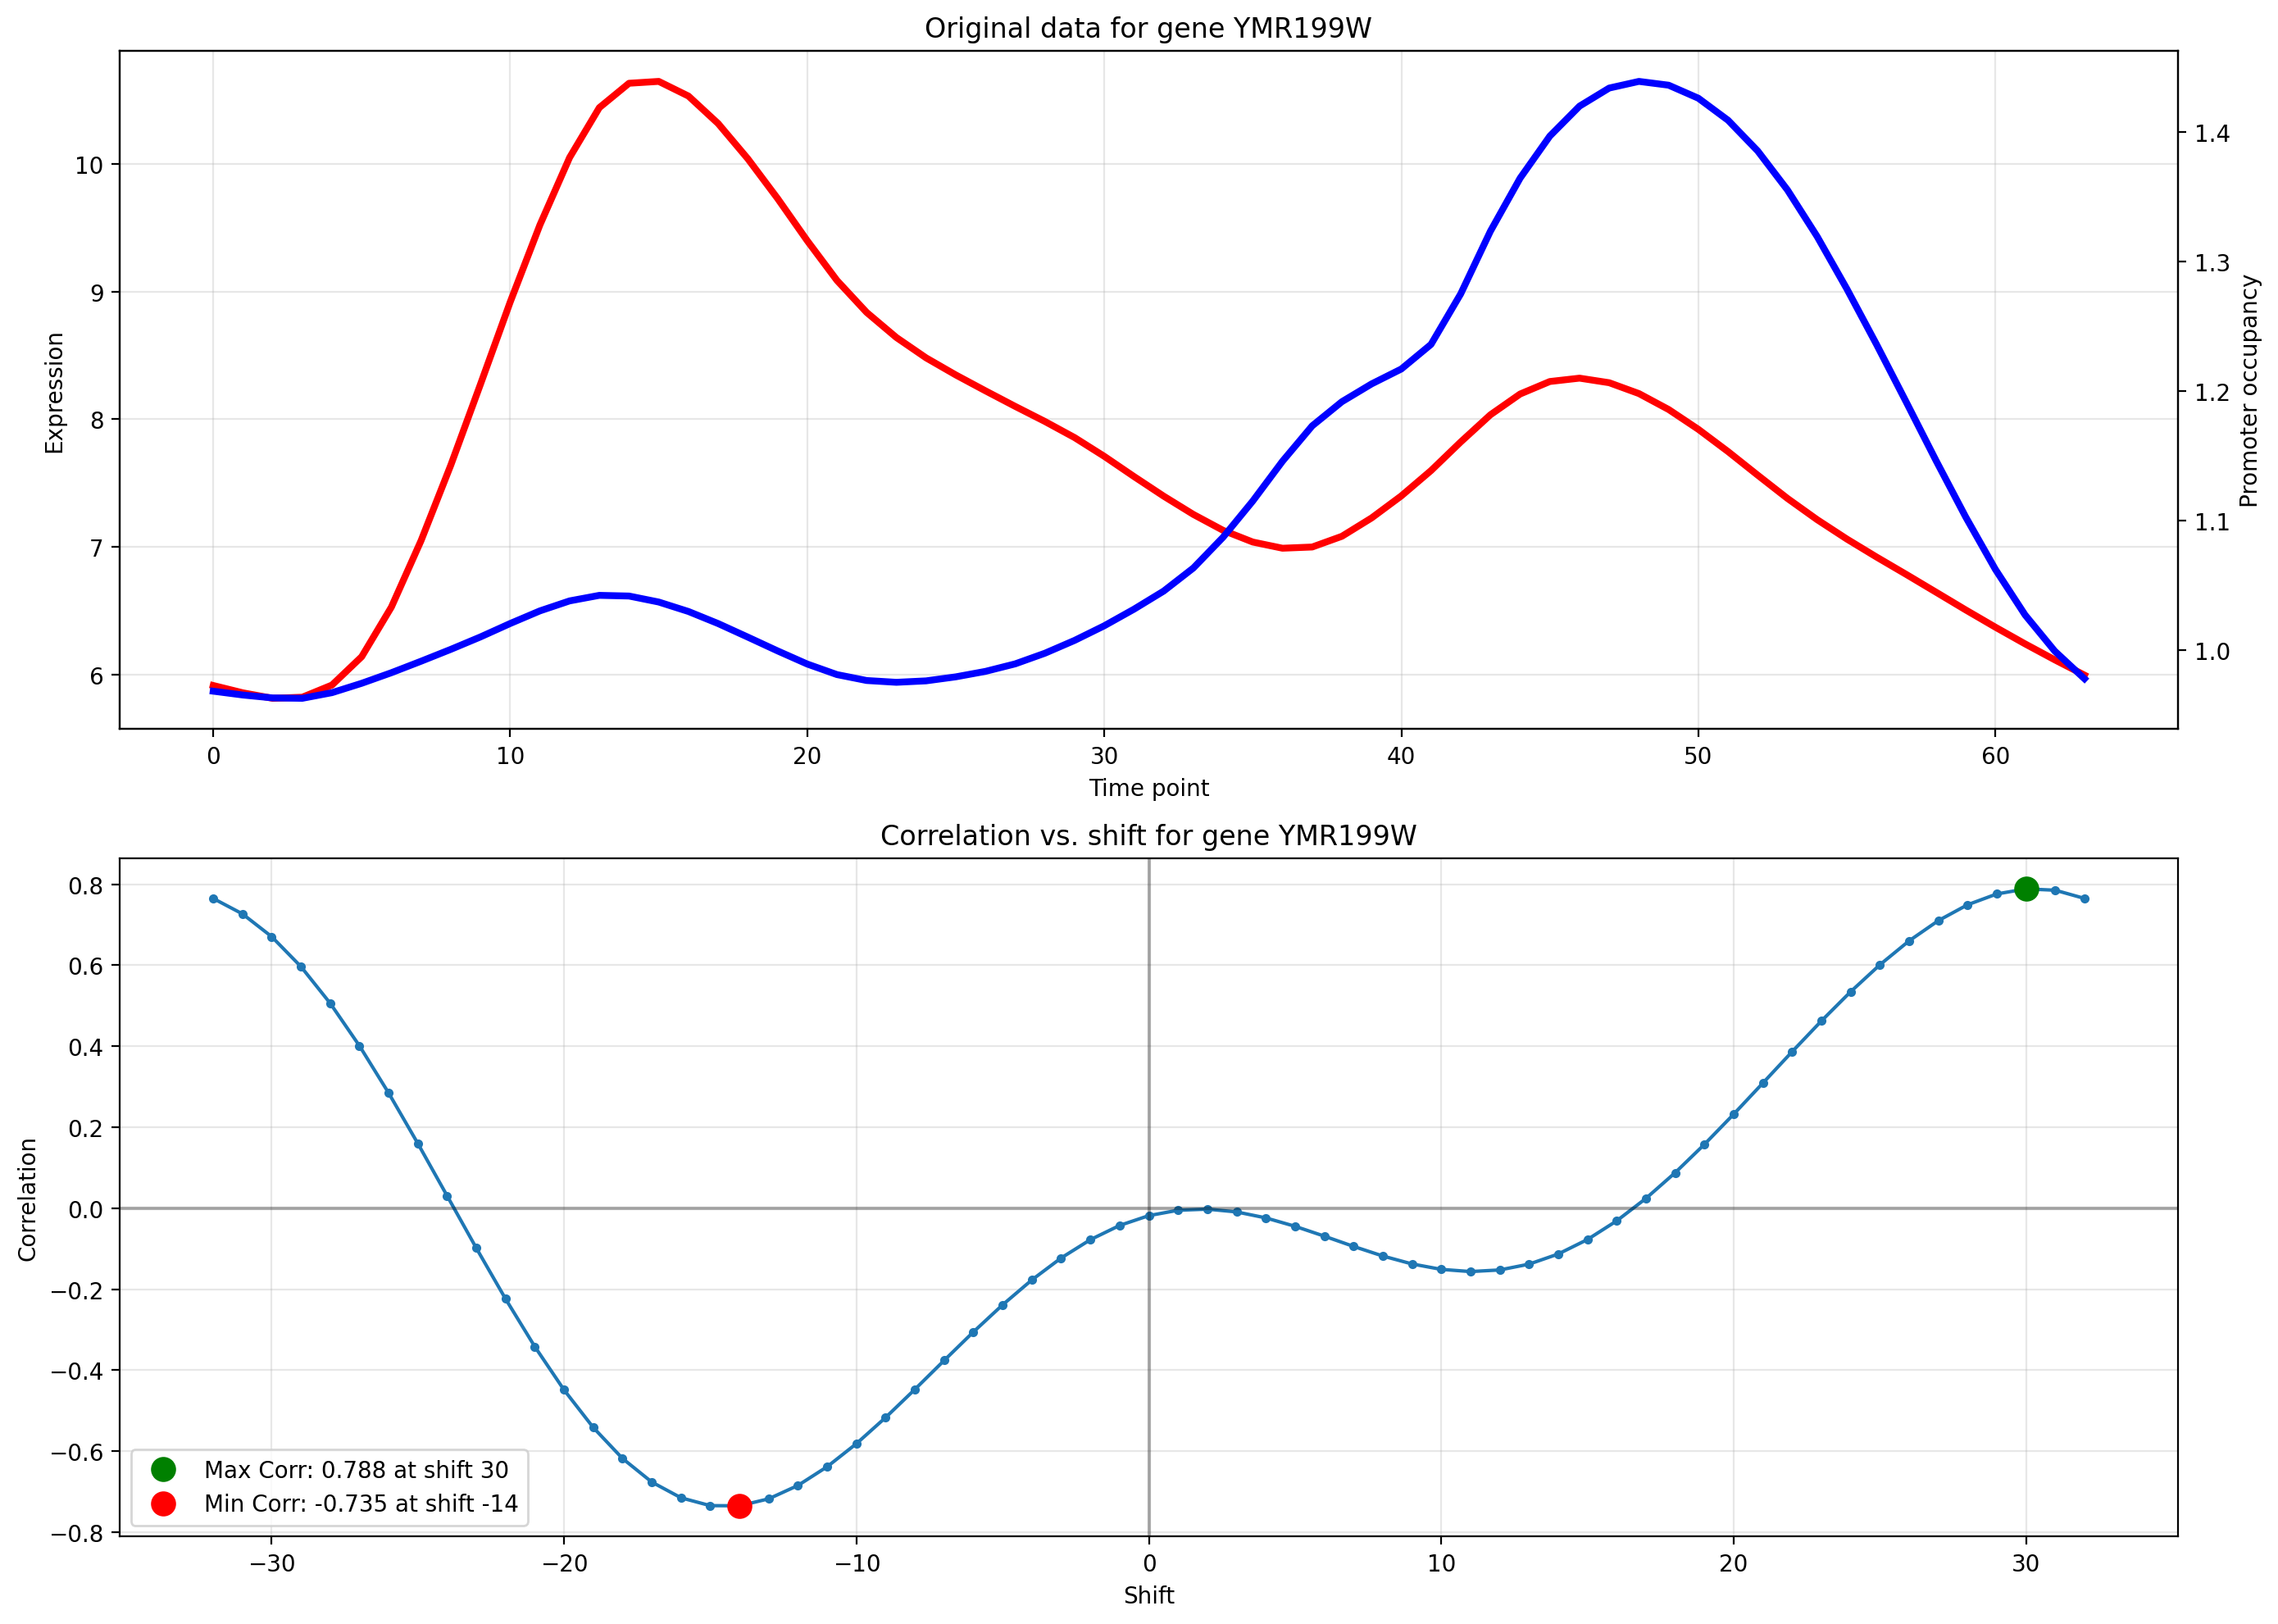

In [589]:
orfname = get_orfname('CLN1')
# Examine a specific gene
fig = analyzer.plot_gene_correlation(orfname, branch_name="daughter")

#fig = analyzer.plot_best_shift_alignment(orfname, 
#    branch_name='daughter')

In [447]:
analyzer.results['mother'].sort_values('max_corr_shift')

,max_corr,max_corr_shift,min_corr,min_corr_shift,regulation_type,abs_max_corr,abs_max_corr_shift,is_positive_correlation
gene,,,,,,,,
YPL034W,0.861330,-32.0,-0.962740,0.0,repressor,0.962740,0.0,False
YLR145W,0.825393,-32.0,-0.851784,0.0,repressor,0.851784,0.0,False
YAL037C-A,0.905072,-32.0,-0.665201,-13.0,activator,0.905072,-32.0,True
YPR021C,0.882016,-32.0,-0.812523,-1.0,activator,0.882016,-32.0,True
YFR038W,0.836186,-32.0,-0.446698,12.0,activator,0.836186,-32.0,True
...,...,...,...,...,...,...,...,...
YJL172W,0.854236,31.0,-0.789165,-17.0,activator,0.854236,31.0,True
YBL008W,0.859982,31.0,-0.863402,-14.0,repressor,0.863402,-14.0,False
YJL013C,0.799492,31.0,-0.674722,-4.0,activator,0.799492,31.0,True


0

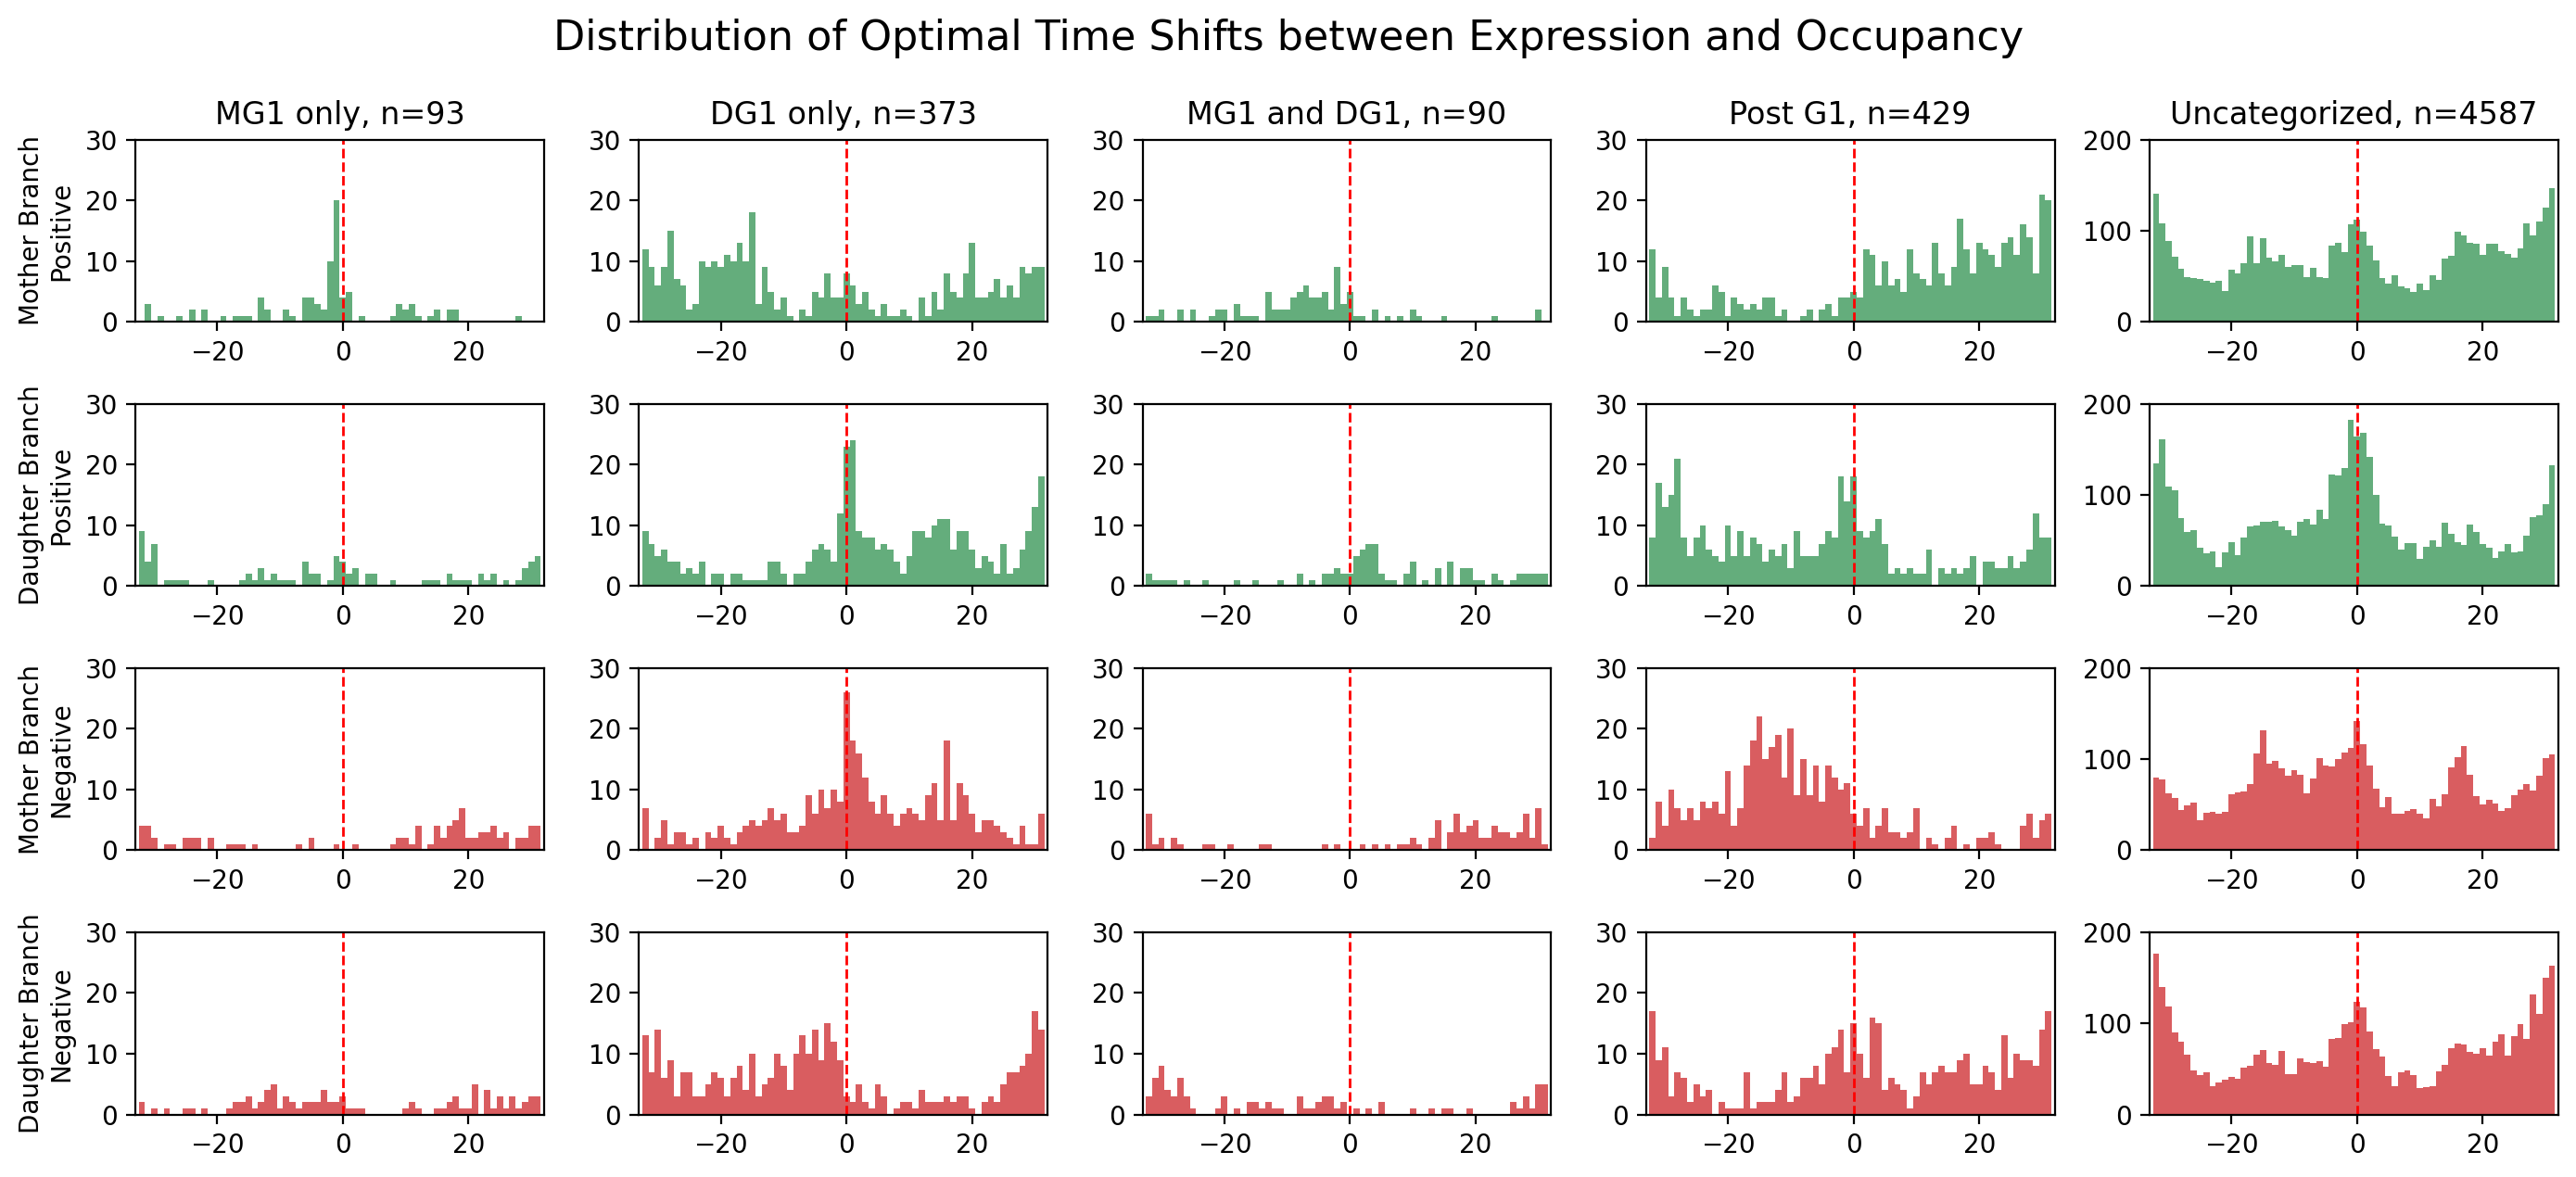

In [501]:

gene_subsets = {
    'MG1 only': mg1_only,
    'DG1 only': dg1_only,
    'MG1 and DG1': mg1_and_dg1,
    'Post G1': postg1_only,
    'Uncategorized': unchanging_orfs
}

analyzer.plot_optimal_shift_distributions(gene_subsets)
0

There are 450 genes with >= 0.21 standard deviation in promoter occupancy (0.9 percentile)


Text(0.5, 1.1, 'Promoter occupancy $\\sigma$ bottom branch, 75th percentile')

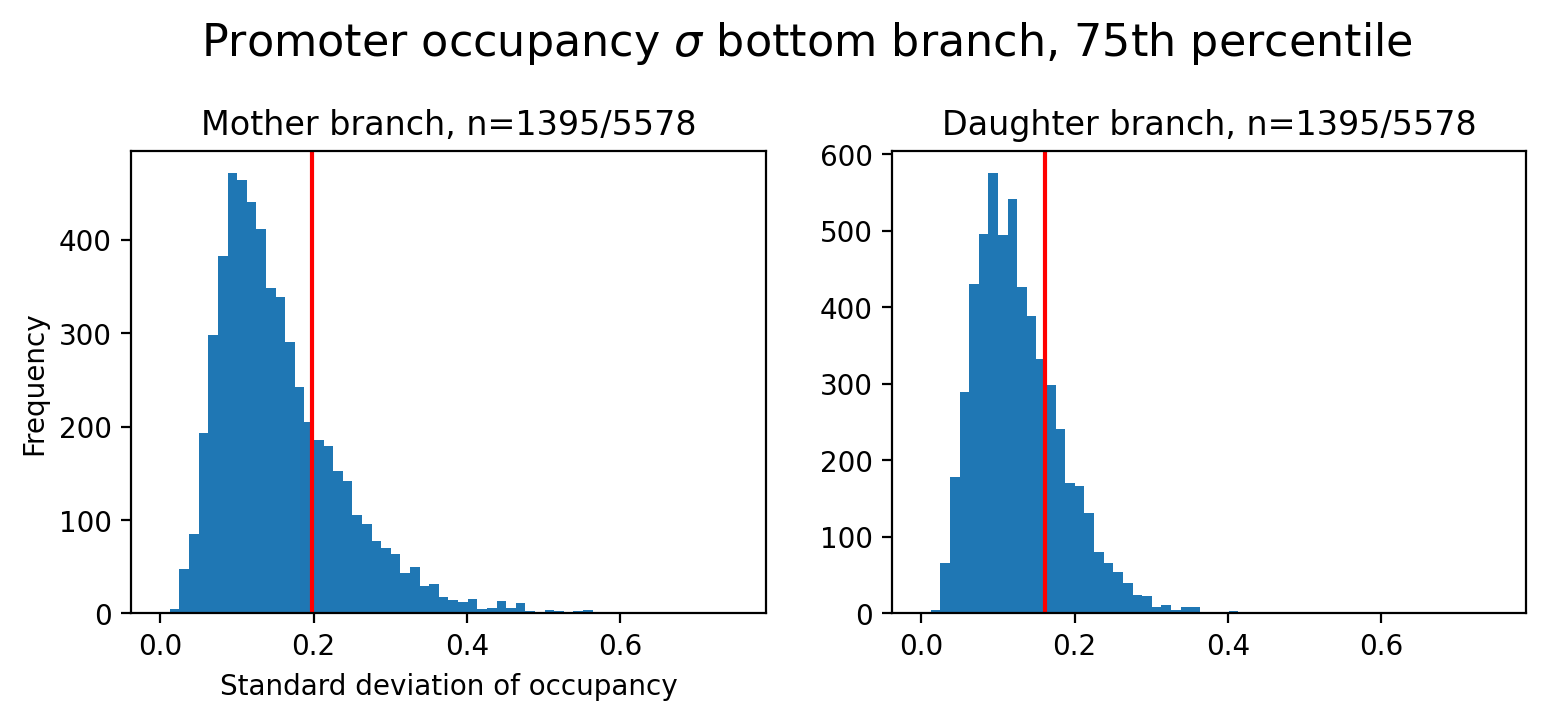

In [678]:

def filter_to_high_std_genes(small_promoter_occupancies_df, indices):
    percentile = 0.75
    small_stds = small_promoter_occupancies_df[indices].std(1)
    qval = np.quantile(small_stds, q=percentile)
    high_std_genes = small_stds[small_stds >= qval].index
    return small_stds, high_std_genes, qval

b_stds, high_b_std_genes, b_qv = filter_to_high_std_genes(small_promoter_occupancies_df, b_indices)
t_stds, high_t_std_genes, t_qv = filter_to_high_std_genes(small_promoter_occupancies_df, t_indices)

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.hist(t_stds, bins=60)
plt.xlabel("Standard deviation of occupancy")
plt.ylabel("Frequency")
plt.title(f"Mother branch, n={len(high_b_std_genes)}/{len(small_promoter_occupancies_df)}")

plt.axvline(t_qv, c='red')
plt.subplot(1, 2, 2)
plt.hist(b_stds, bins=60)
plt.axvline(b_qv, c='red')
plt.title(f"Daughter branch, n={len(high_t_std_genes)}/{len(small_promoter_occupancies_df)}")

high_std_genes = set(high_b_std_genes).intersection(high_t_std_genes)

print(f"There are {len(high_std_genes)} genes with >= {qval:.2f} "
      f"standard deviation in promoter occupancy ({percentile} percentile)")
plt.suptitle(f"Promoter occupancy $\sigma$ bottom branch, 75th percentile",
             y=1.1, fontsize=16)


MG1 only (high std): 33 genes
DG1 only (high std): 114 genes
MG1 and DG1 (high std): 27 genes
Post G1 (high std): 114 genes
Uncategorized (high std): 1105 genes


0

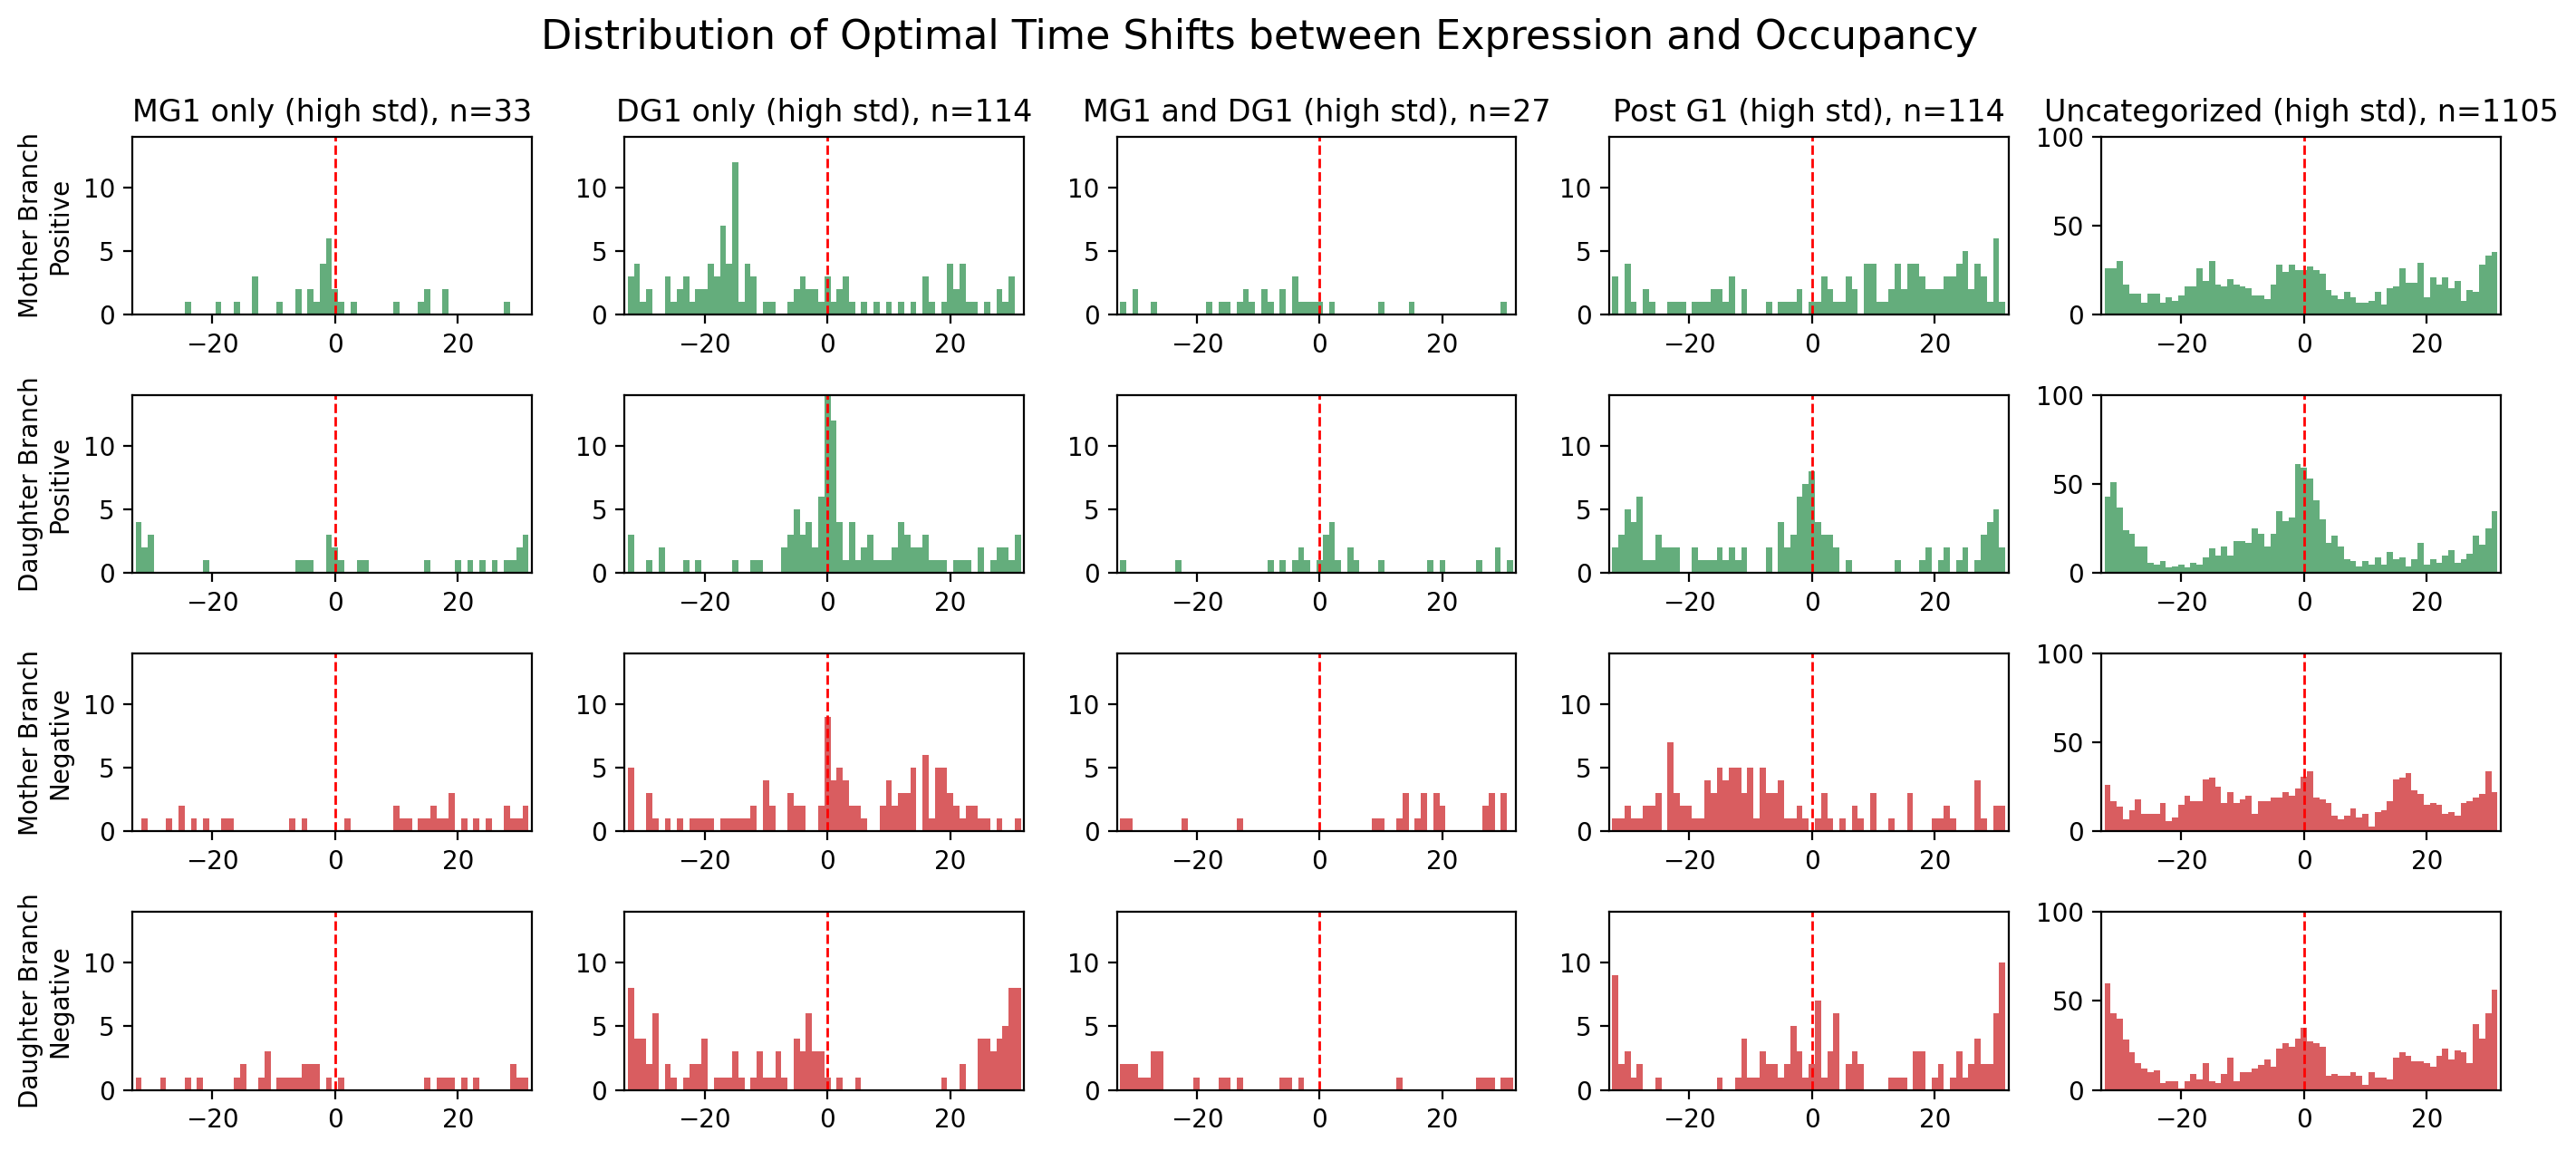

In [635]:
# Create filtered gene subsets that only include genes from high_std_genes
d_filtered_gene_subsets = {}
high_std_genes = high_b_std_genes

for subset_name, gene_list in gene_subsets.items():
    # Find the intersection between this subset and high_std_genes
    filtered_genes = [gene for gene in gene_list if gene in high_std_genes]
    
    # Only include the subset if it has genes after filtering
    if filtered_genes:
        d_filtered_gene_subsets[f'{subset_name} (high std)'] = filtered_genes

# Print the number of genes in each filtered subset
for name, genes in d_filtered_gene_subsets.items():
    print(f"{name}: {len(genes)} genes")

analyzer.plot_optimal_shift_distributions(d_filtered_gene_subsets)
0

MG1 only (high std): 26 genes
DG1 only (high std): 94 genes
MG1 and DG1 (high std): 28 genes
Post G1 (high std): 106 genes
Uncategorized (high std): 1138 genes


0

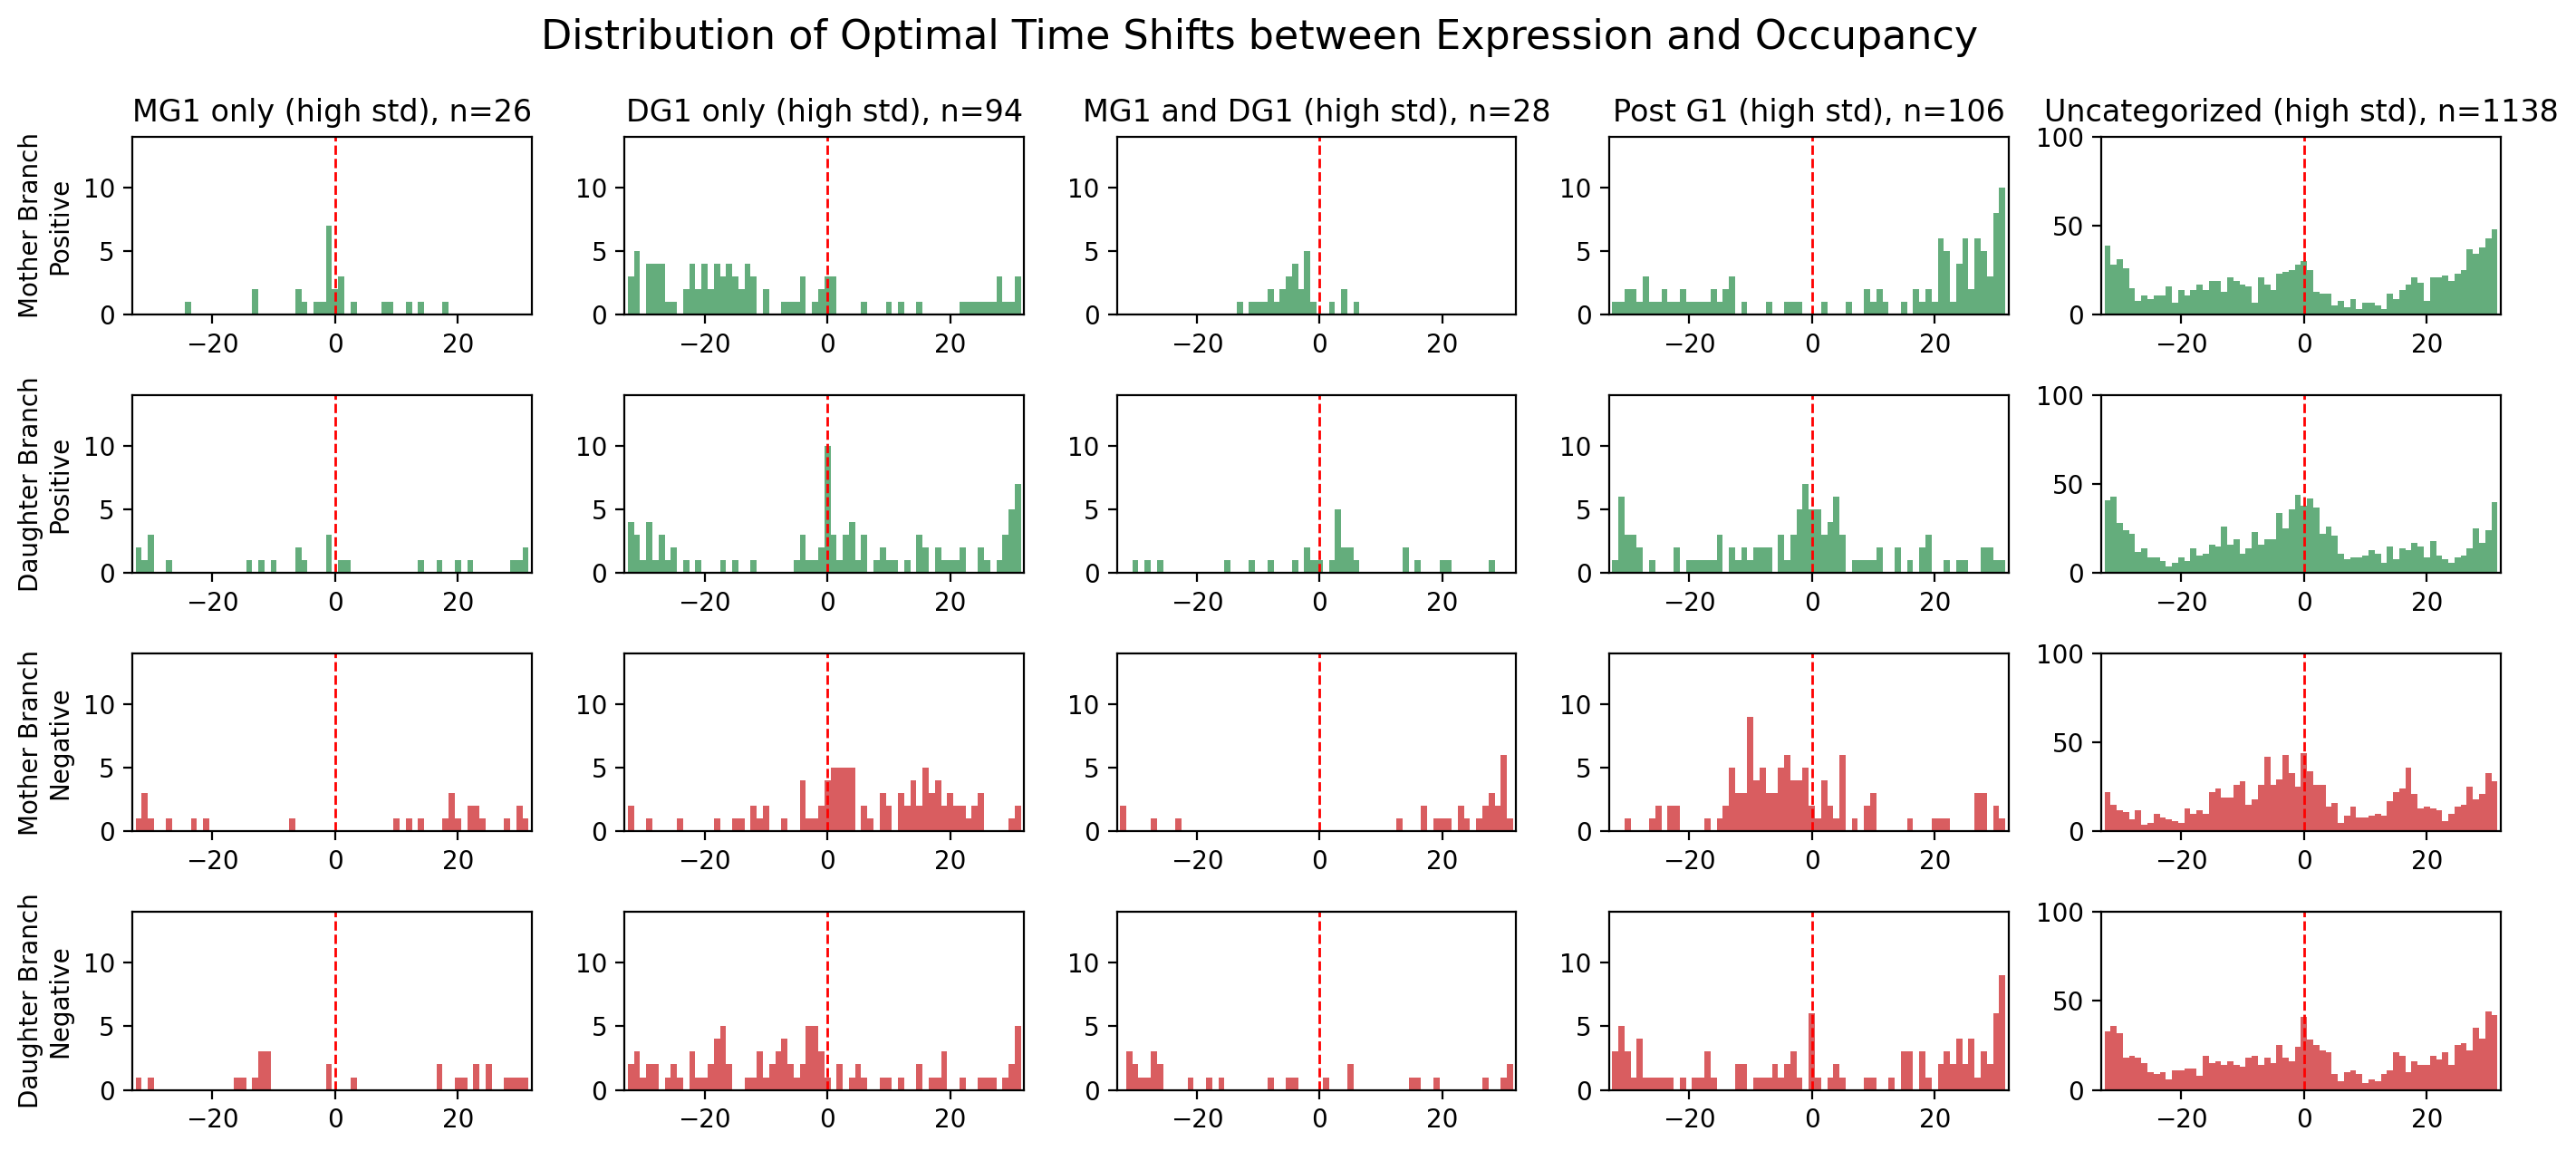

In [636]:
# Create filtered gene subsets that only include genes from high_std_genes
m_filtered_gene_subsets = {}
high_std_genes = high_t_std_genes

for subset_name, gene_list in gene_subsets.items():
    # Find the intersection between this subset and high_std_genes
    filtered_genes = [gene for gene in gene_list if gene in high_std_genes]
    
    # Only include the subset if it has genes after filtering
    if filtered_genes:
        m_filtered_gene_subsets[f'{subset_name} (high std)'] = filtered_genes

# Print the number of genes in each filtered subset
for name, genes in m_filtered_gene_subsets.items():
    print(f"{name}: {len(genes)} genes")

analyzer.plot_optimal_shift_distributions(m_filtered_gene_subsets)
0

In [648]:
# Now let's see if we have better examples

dg_only_high_std_orfs = m_filtered_gene_subsets['DG1 only (high std)']
selected_dg_correlations = analyzer.results['daughter'].loc[dg_only_high_std_orfs].sort_values('max_corr_shift')

selected_dg_correlations[selected_dg_correlations.max_corr_shift < 20]

,max_corr,max_corr_shift,min_corr,min_corr_shift,regulation_type,abs_max_corr,abs_max_corr_shift,is_positive_correlation
gene,,,,,,,,
YDR180W,0.734394,-32.0,-0.811089,-17.0,repressor,0.811089,-17.0,False
YDR507C,0.703817,-32.0,-0.777563,-16.0,repressor,0.777563,-16.0,False
YDL156W,0.887074,-32.0,-0.666951,-4.0,activator,0.887074,-32.0,True
YDL105W,0.857819,-32.0,-0.640091,-7.0,activator,0.857819,-32.0,True
YCL047C,0.384525,-31.0,-0.196358,12.0,unclear,0.384525,-31.0,True
...,...,...,...,...,...,...,...,...
YDL149W,0.721286,16.0,-0.755171,-17.0,repressor,0.755171,-17.0,False
YNL273W,0.574579,16.0,-0.587067,-19.0,repressor,0.587067,-19.0,False
YLL041C,0.802991,18.0,-0.859934,-7.0,repressor,0.859934,-7.0,False


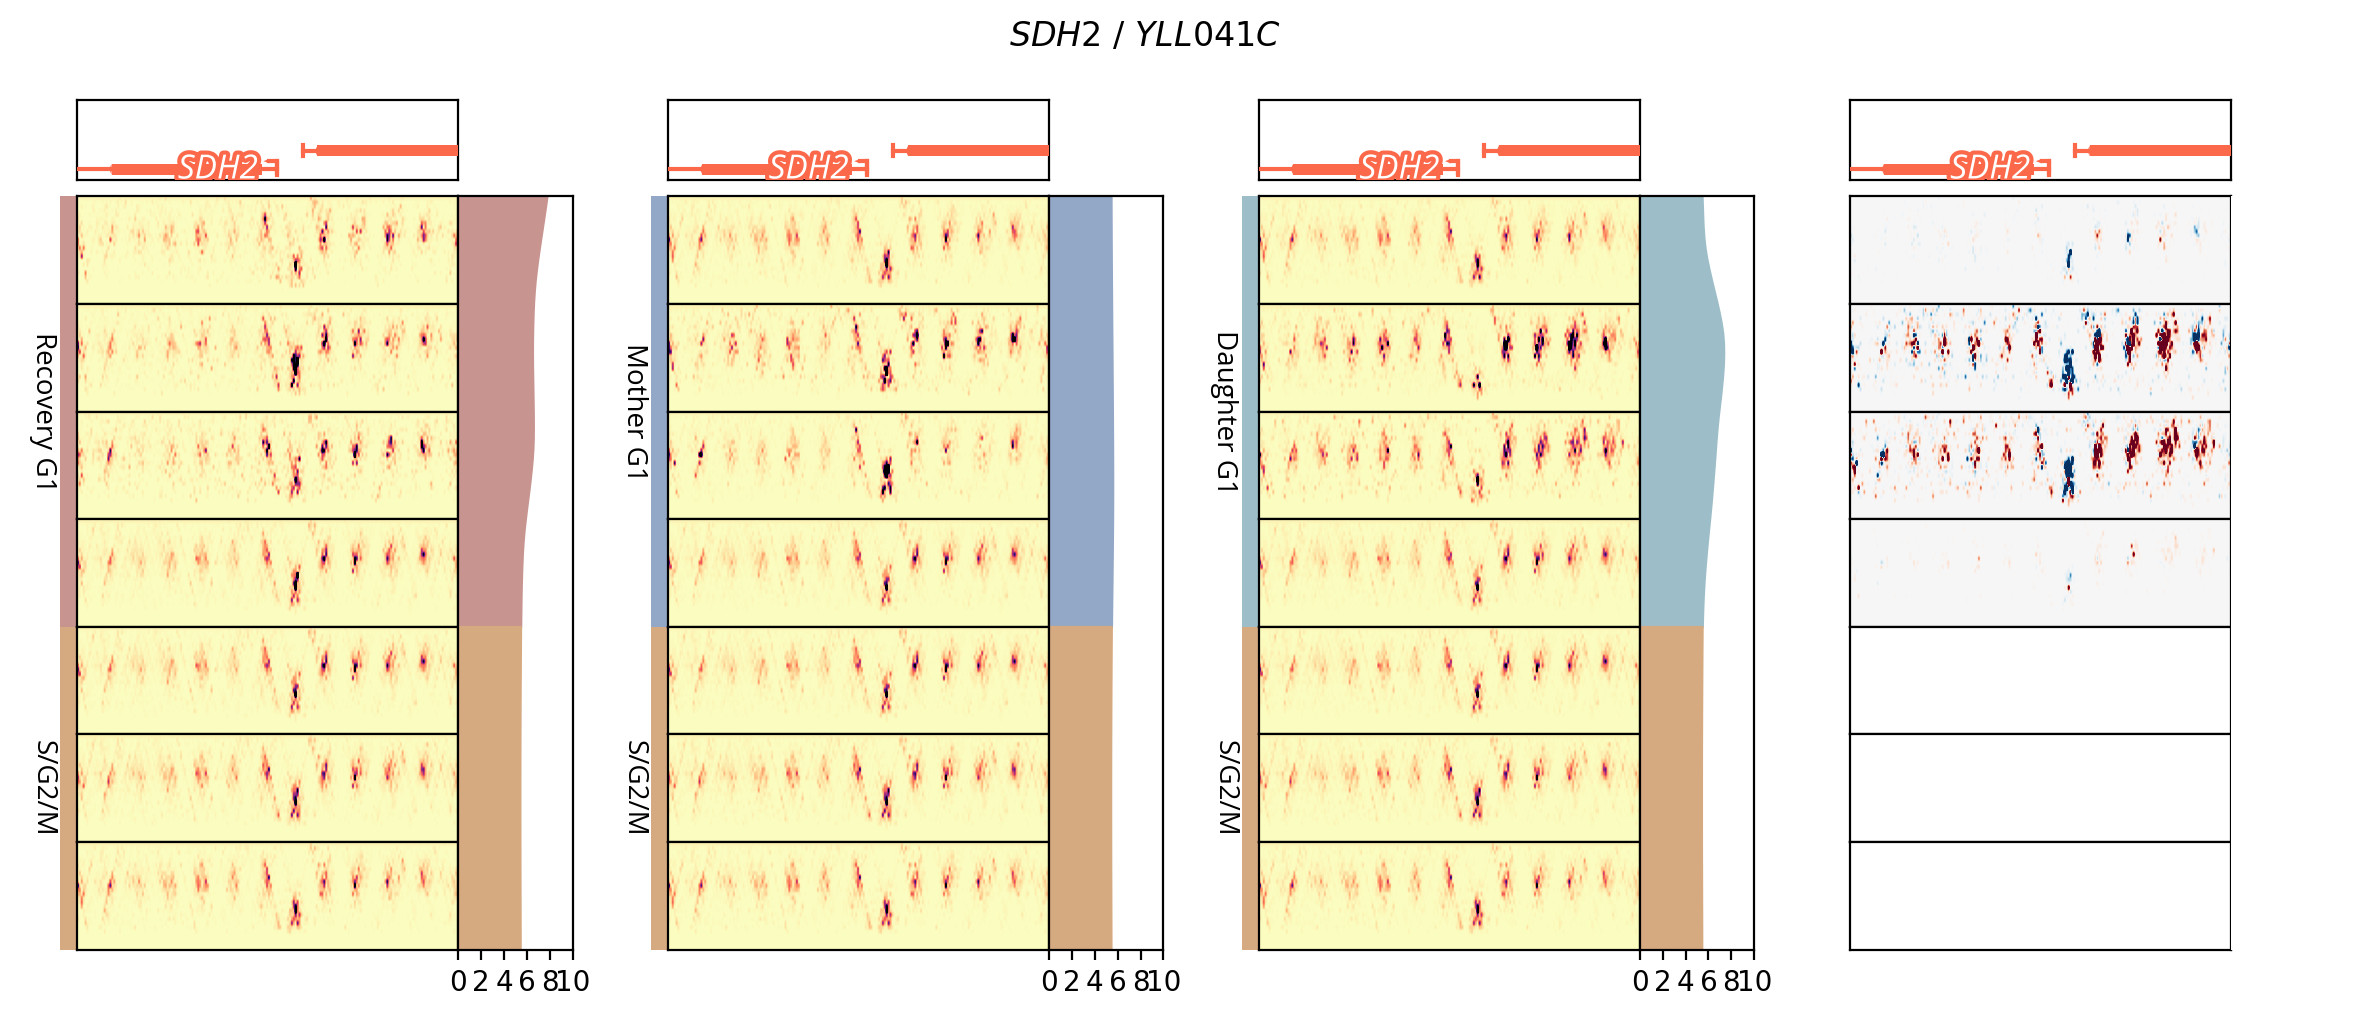

In [649]:
fig = genome_analysis.plot_gene('YLL041C', config1, analysis)

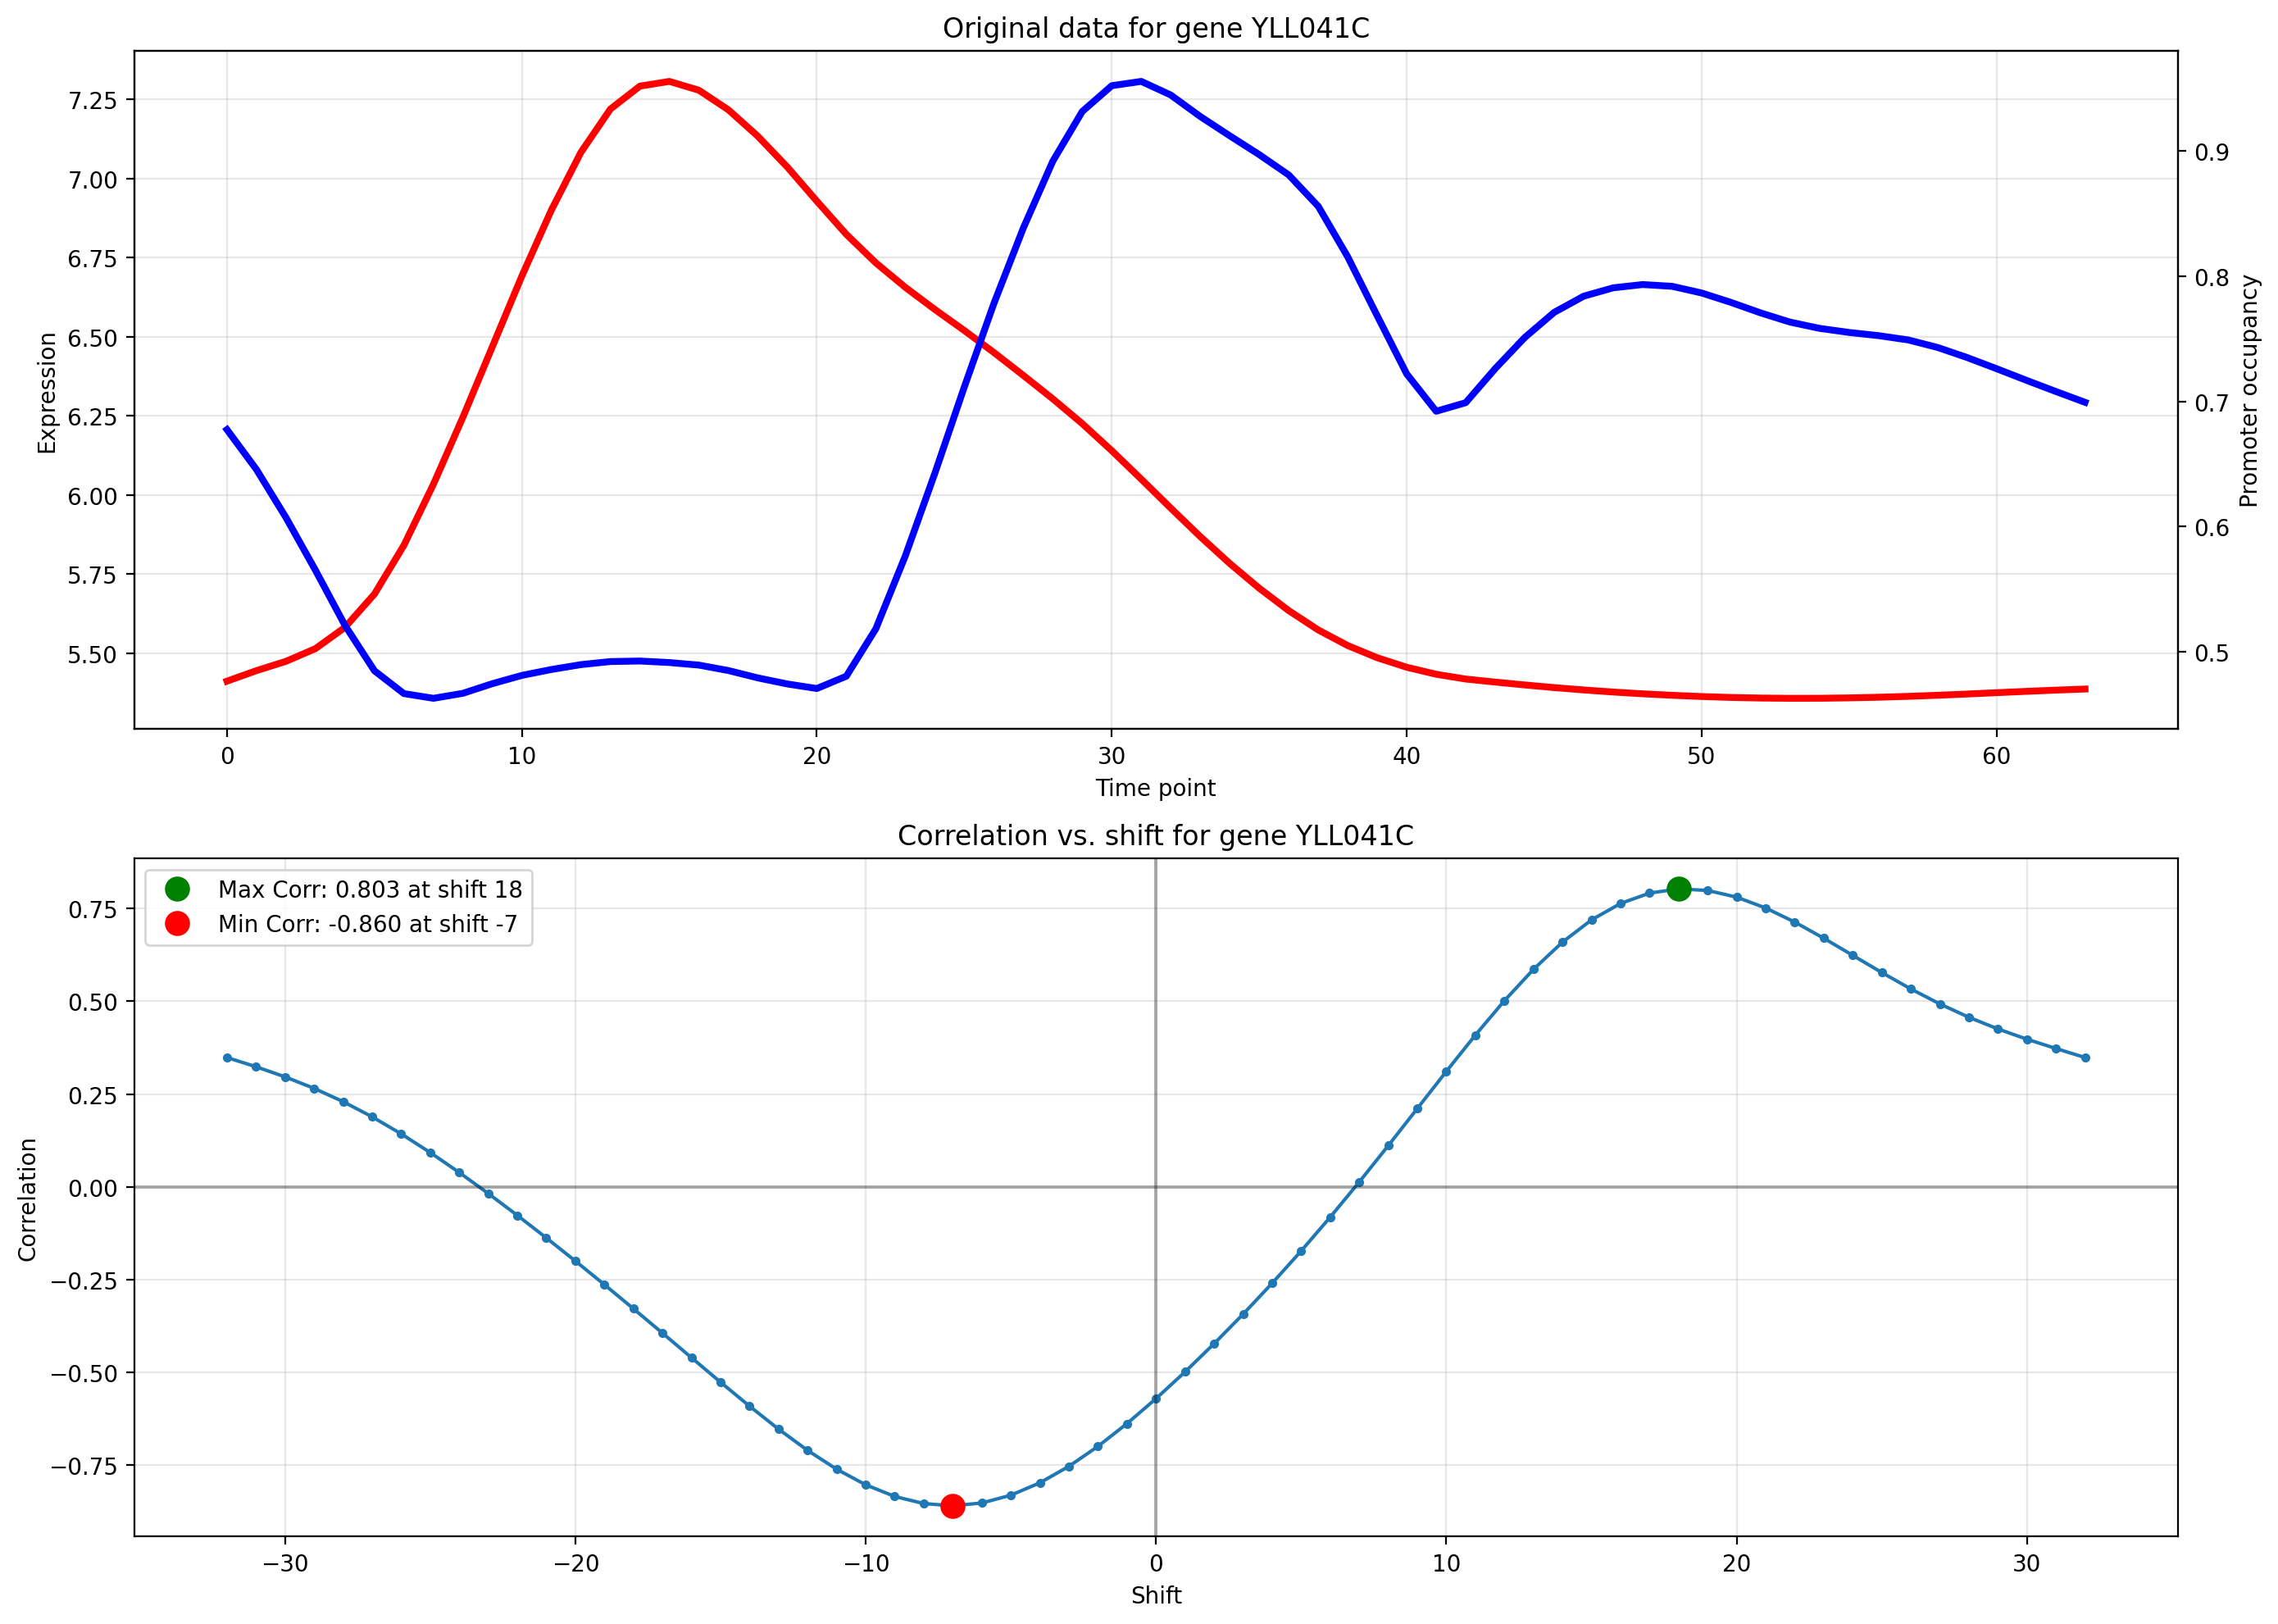

In [650]:
orfname = get_orfname('YLL041C')
fig = analyzer.plot_gene_correlation(orfname, branch_name="daughter")


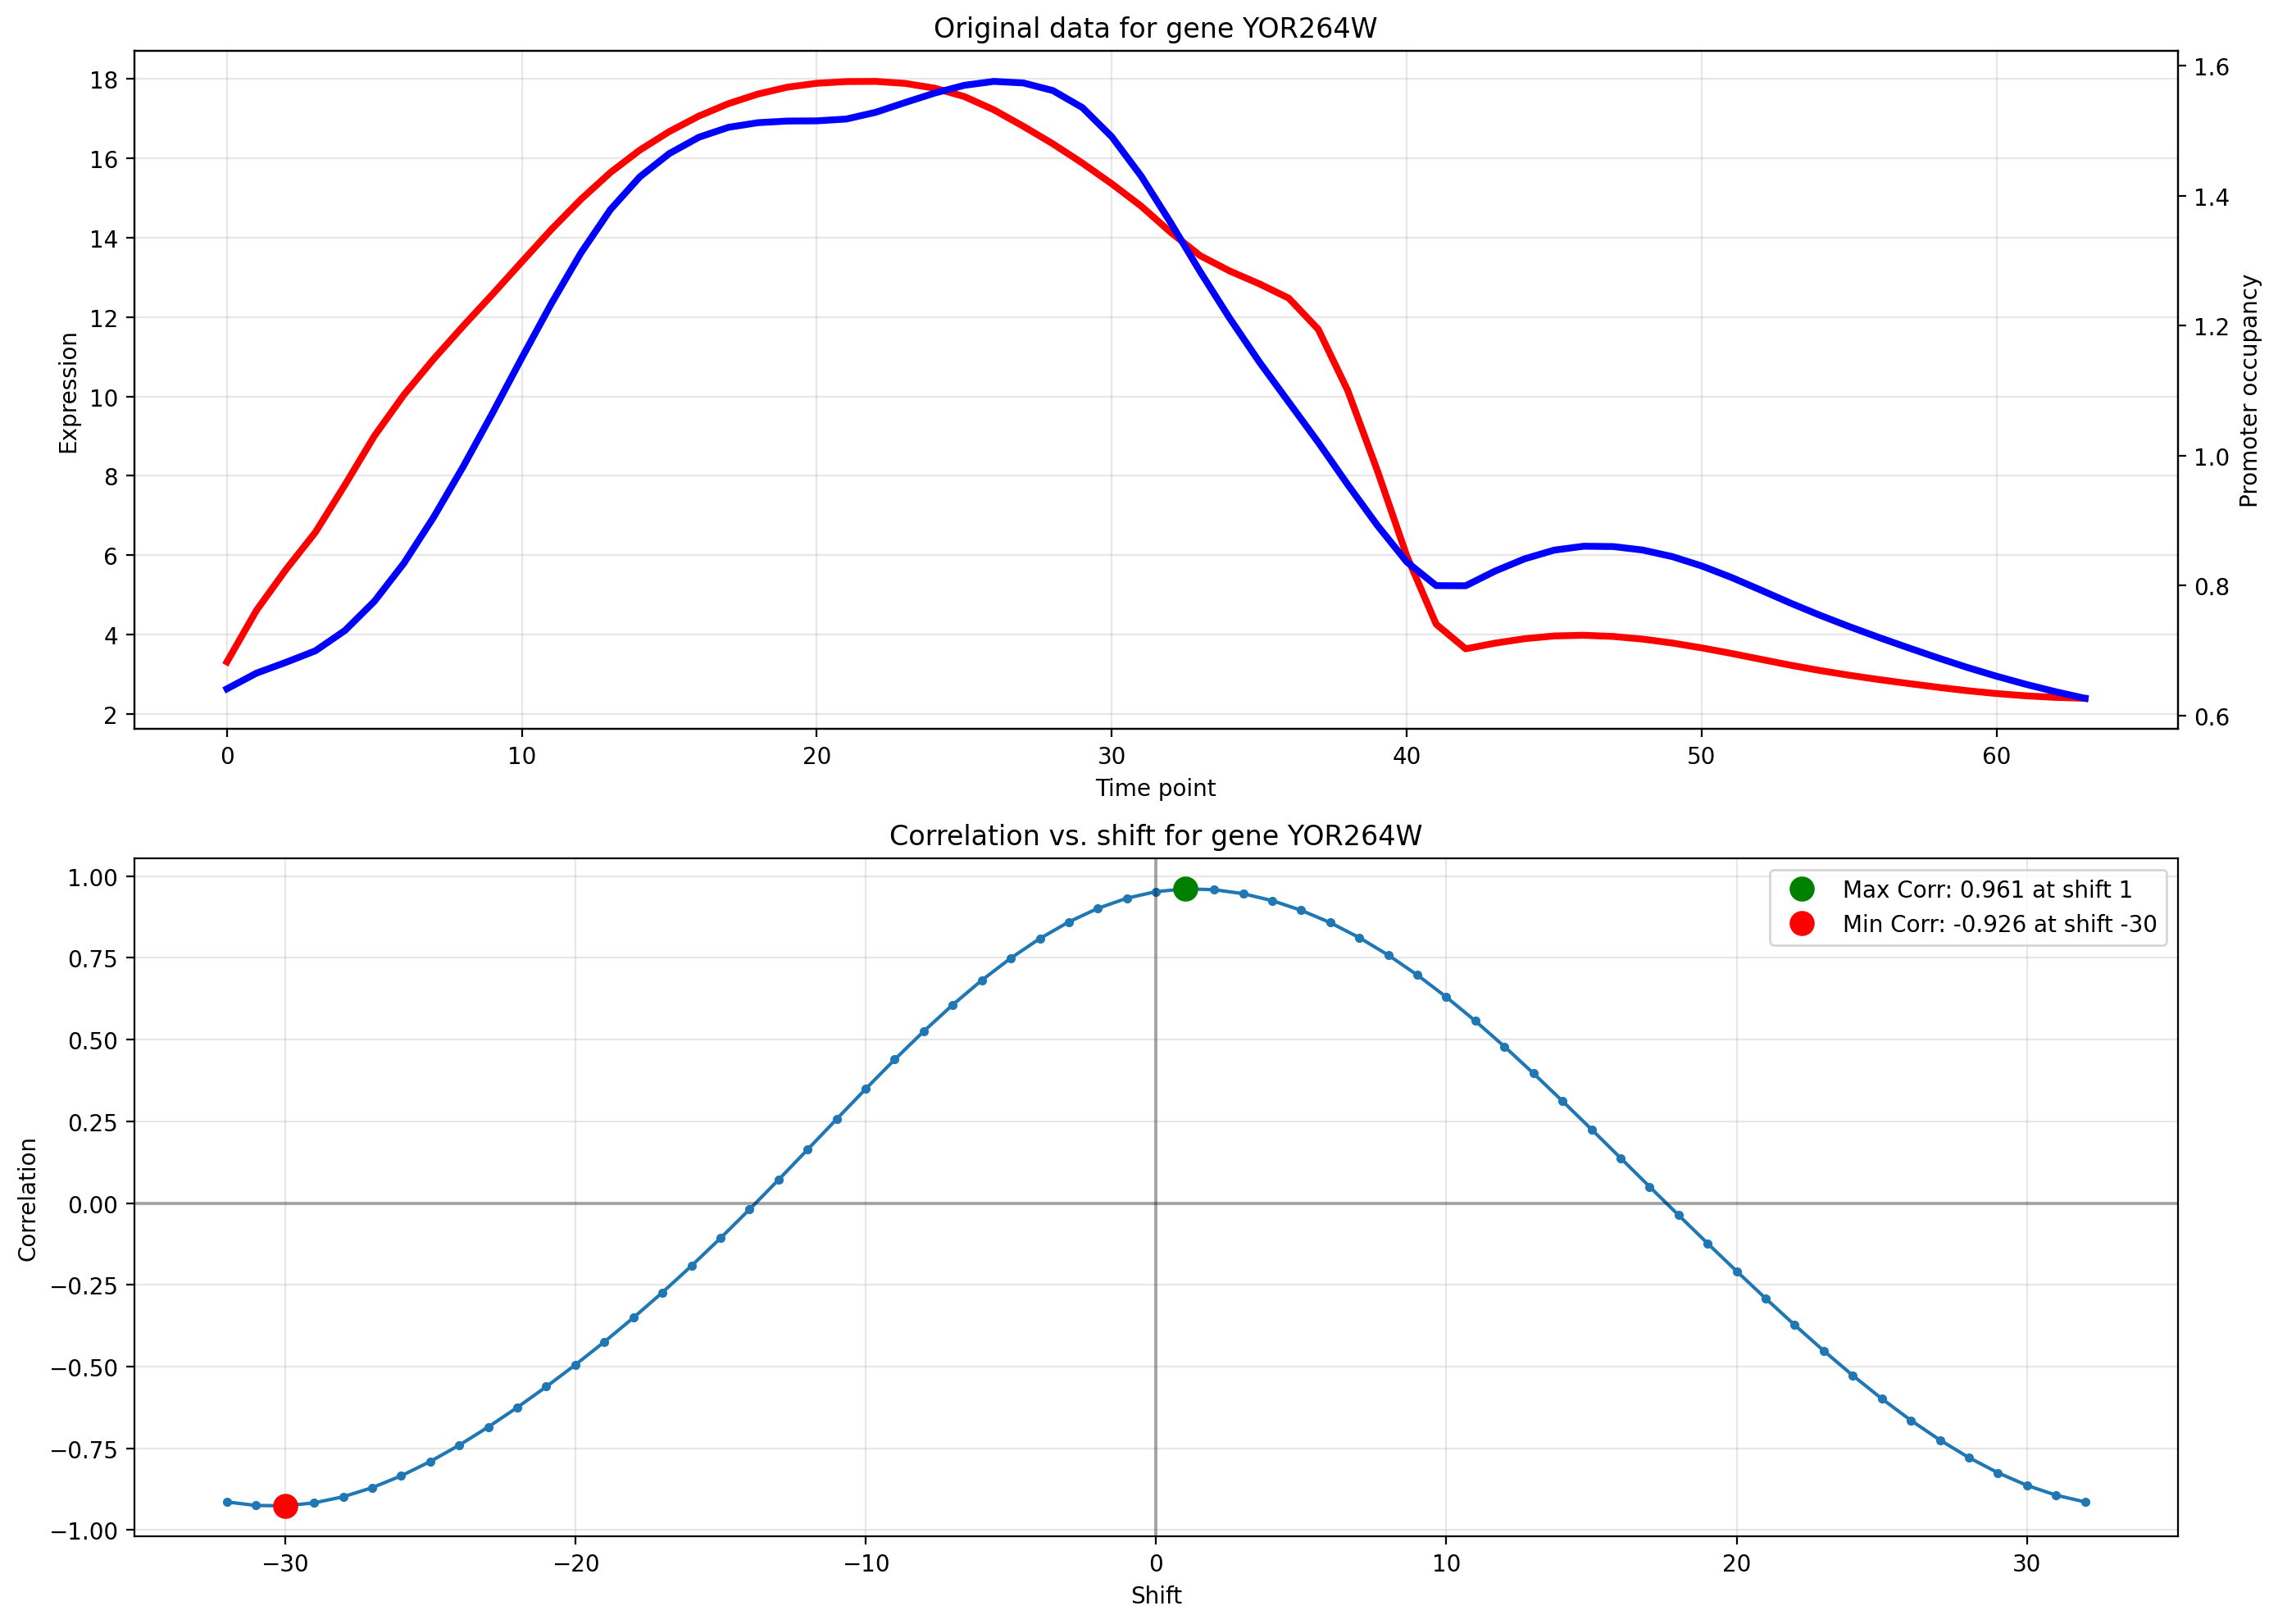

In [658]:
orfname = get_orfname('DSE3')
fig = analyzer.plot_gene_correlation(orfname, branch_name="daughter")


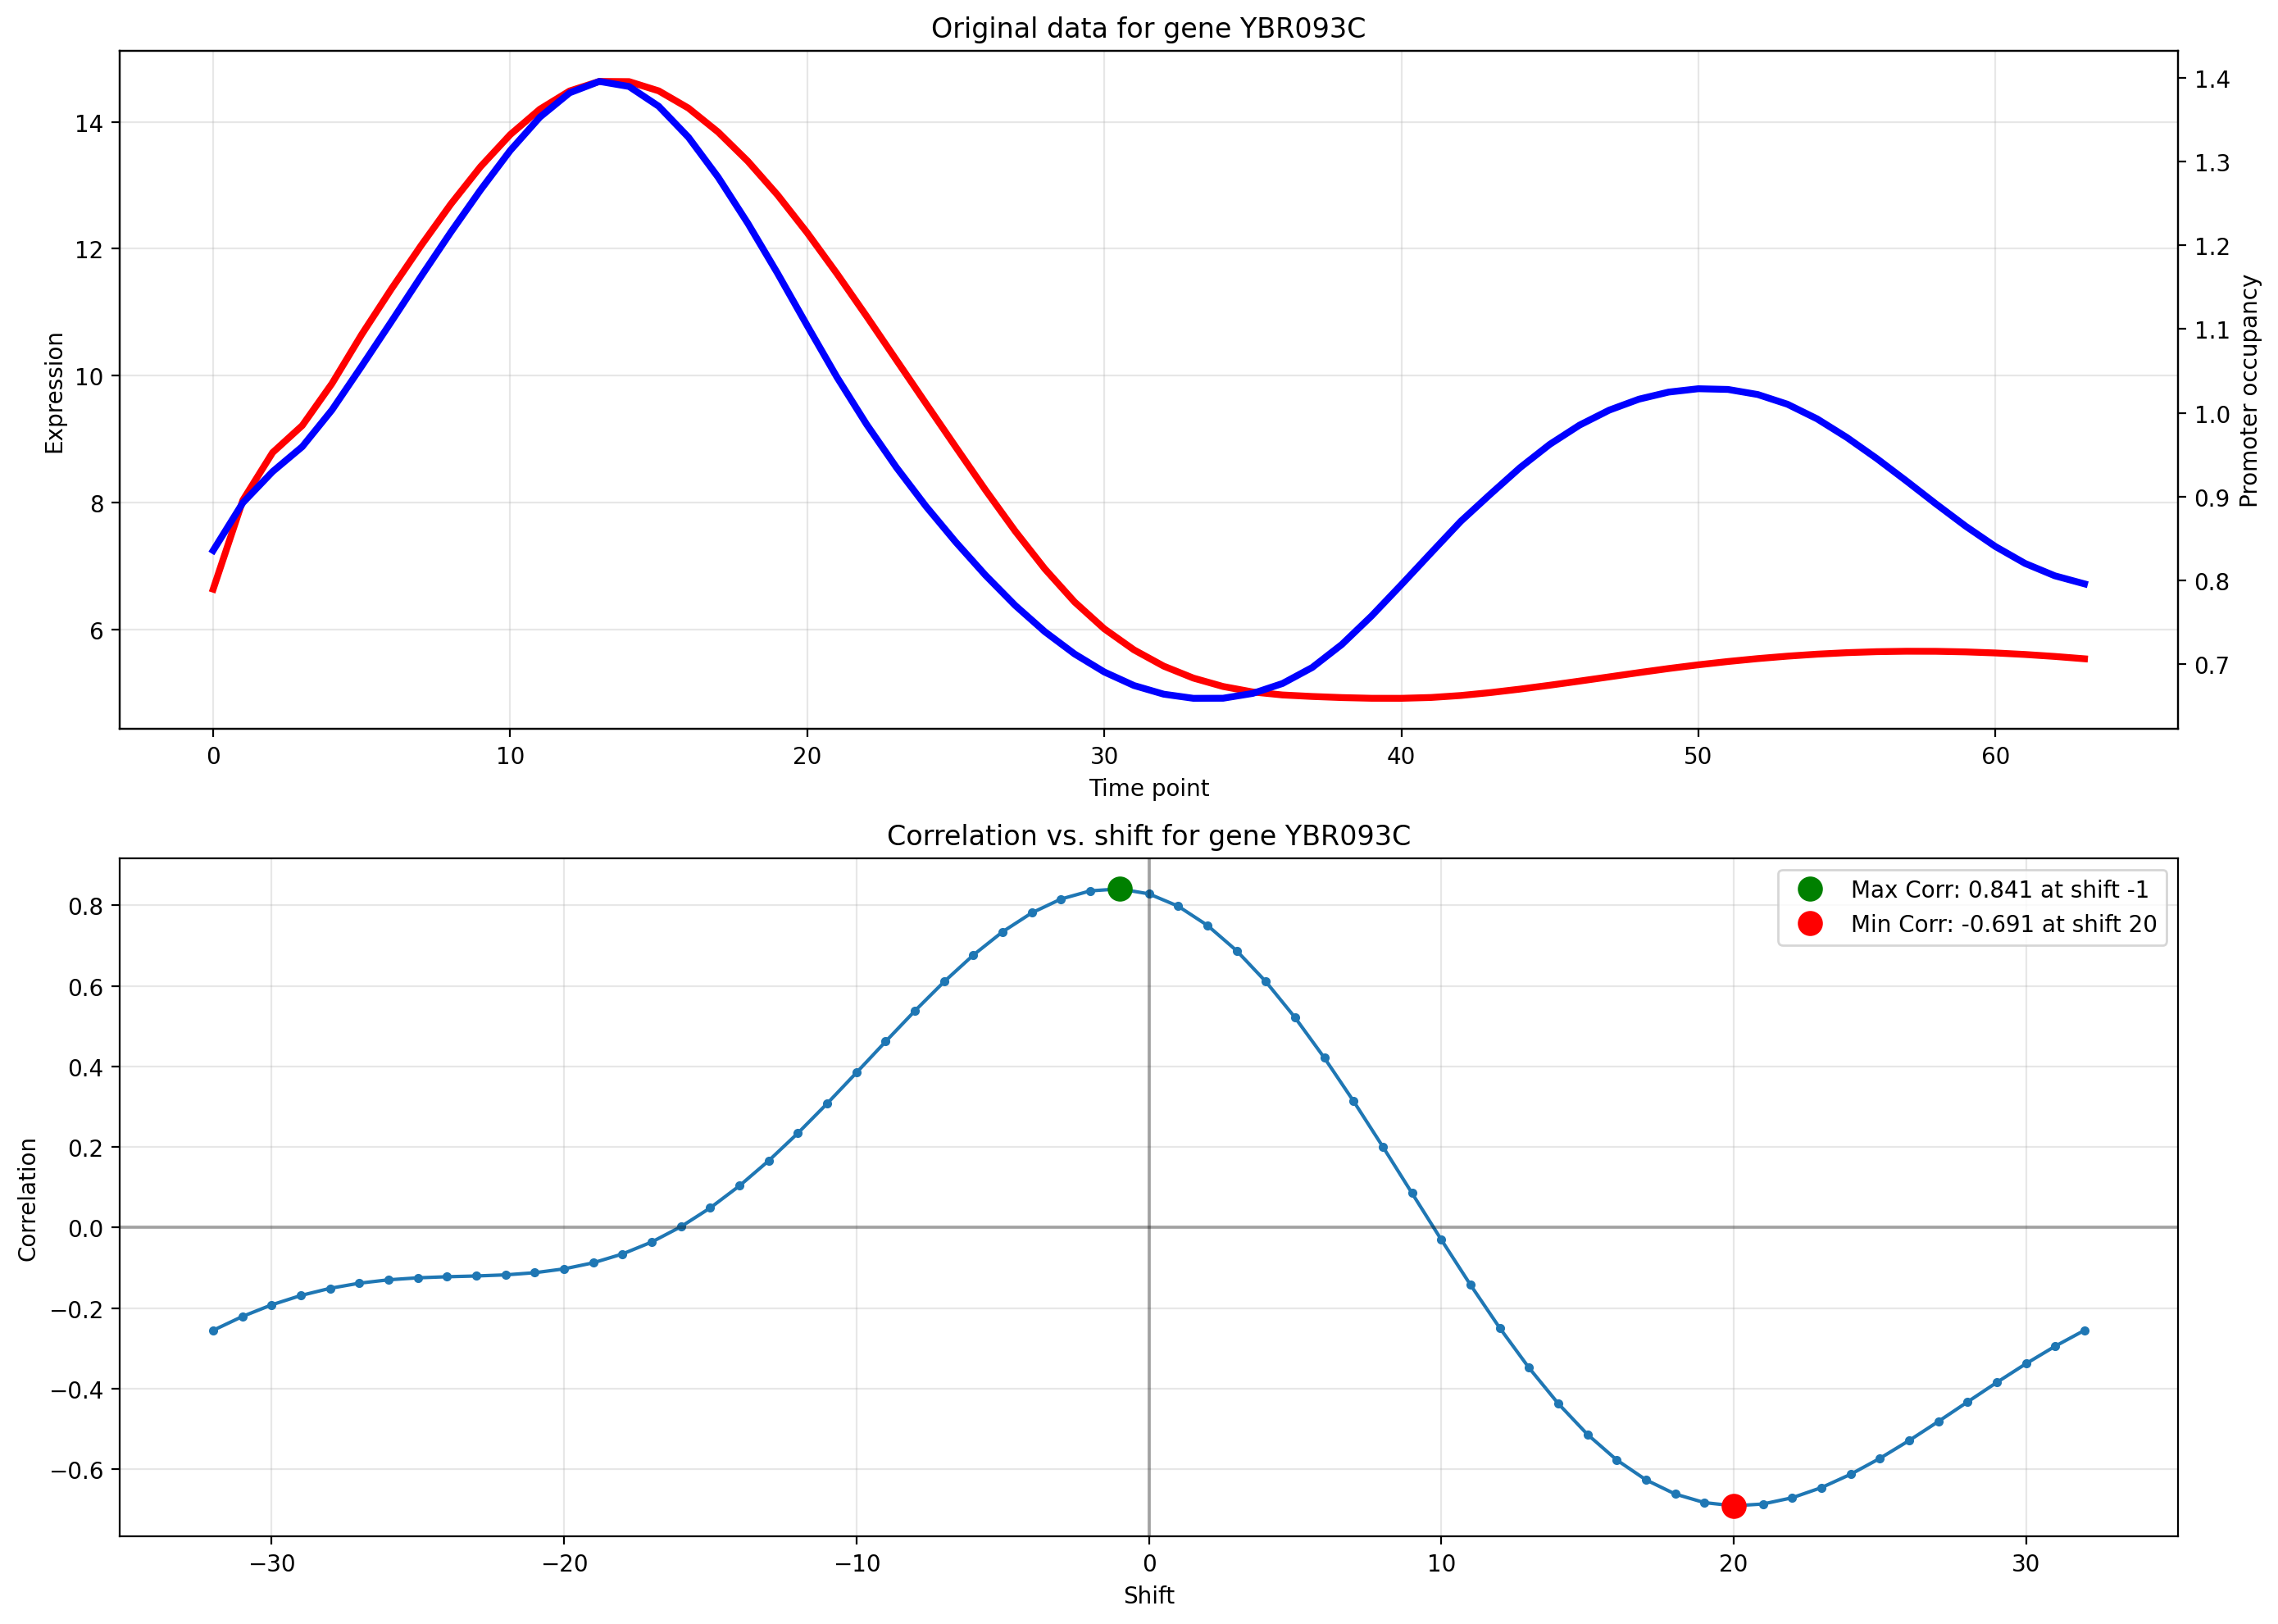

In [656]:
orfname = get_orfname('PHO5')
fig = analyzer.plot_gene_correlation(orfname, branch_name="mother")


In [661]:
# Now let's see if we have better examples

postg1_only_high_std_orfs = m_filtered_gene_subsets['Post G1 (high std)']
selected_dg_correlations = analyzer.results['mother'].loc[postg1_only_high_std_orfs].sort_values('max_corr_shift')

selected_dg_correlations[selected_dg_correlations.max_corr_shift > -20]


,max_corr,max_corr_shift,min_corr,min_corr_shift,regulation_type,abs_max_corr,abs_max_corr_shift,is_positive_correlation
gene,,,,,,,,
YOL124C,0.563644,-19.0,-0.509470,3.0,activator,0.563644,-19.0,True
YKL078W,0.863602,-18.0,-0.705581,2.0,activator,0.863602,-18.0,True
YNL191W,0.784816,-17.0,-0.762671,27.0,activator,0.784816,-17.0,True
YNL318C,0.648461,-16.0,-0.480347,16.0,activator,0.648461,-16.0,True
YOL151W,0.816890,-16.0,-0.483362,7.0,activator,0.816890,-16.0,True
...,...,...,...,...,...,...,...,...
YNR058W,0.882385,31.0,-0.875941,-1.0,activator,0.882385,31.0,True
YEL047C,0.962398,31.0,-0.689710,-10.0,activator,0.962398,31.0,True
YDR380W,0.932446,31.0,-0.760240,-13.0,activator,0.932446,31.0,True


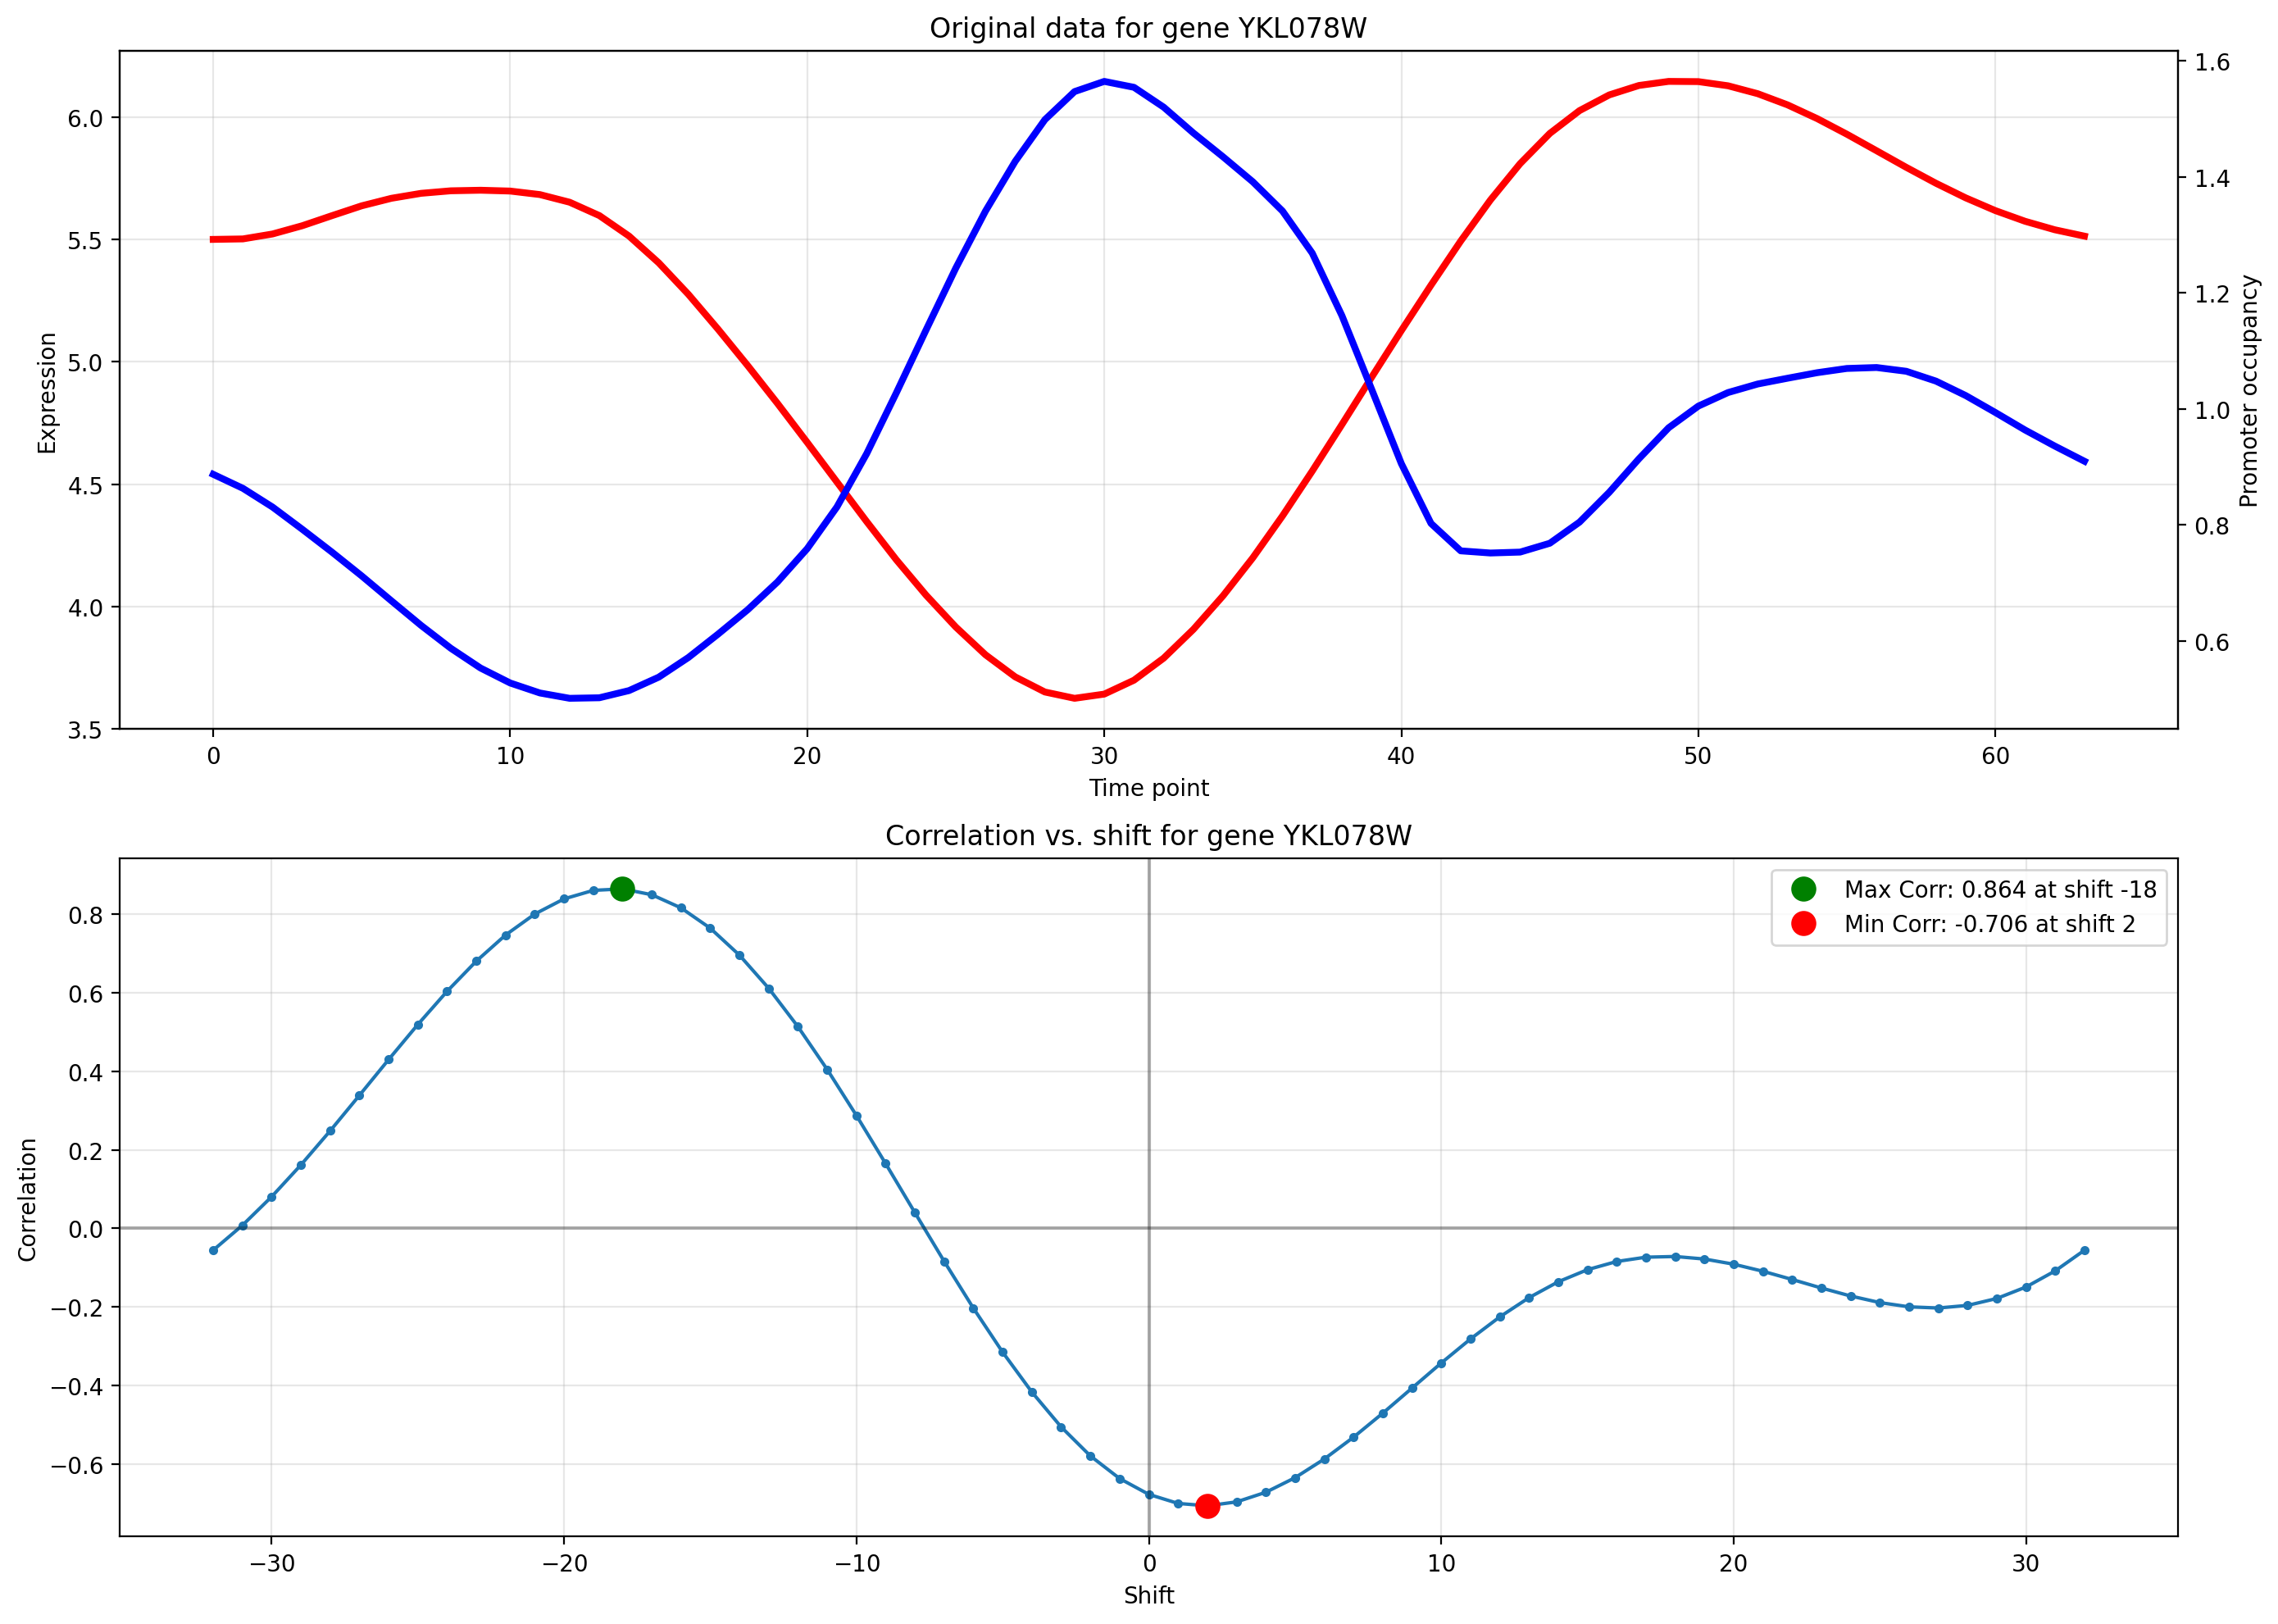

In [662]:
orfname = get_orfname('YKL078W')
fig = analyzer.plot_gene_correlation(orfname, branch_name="mother")


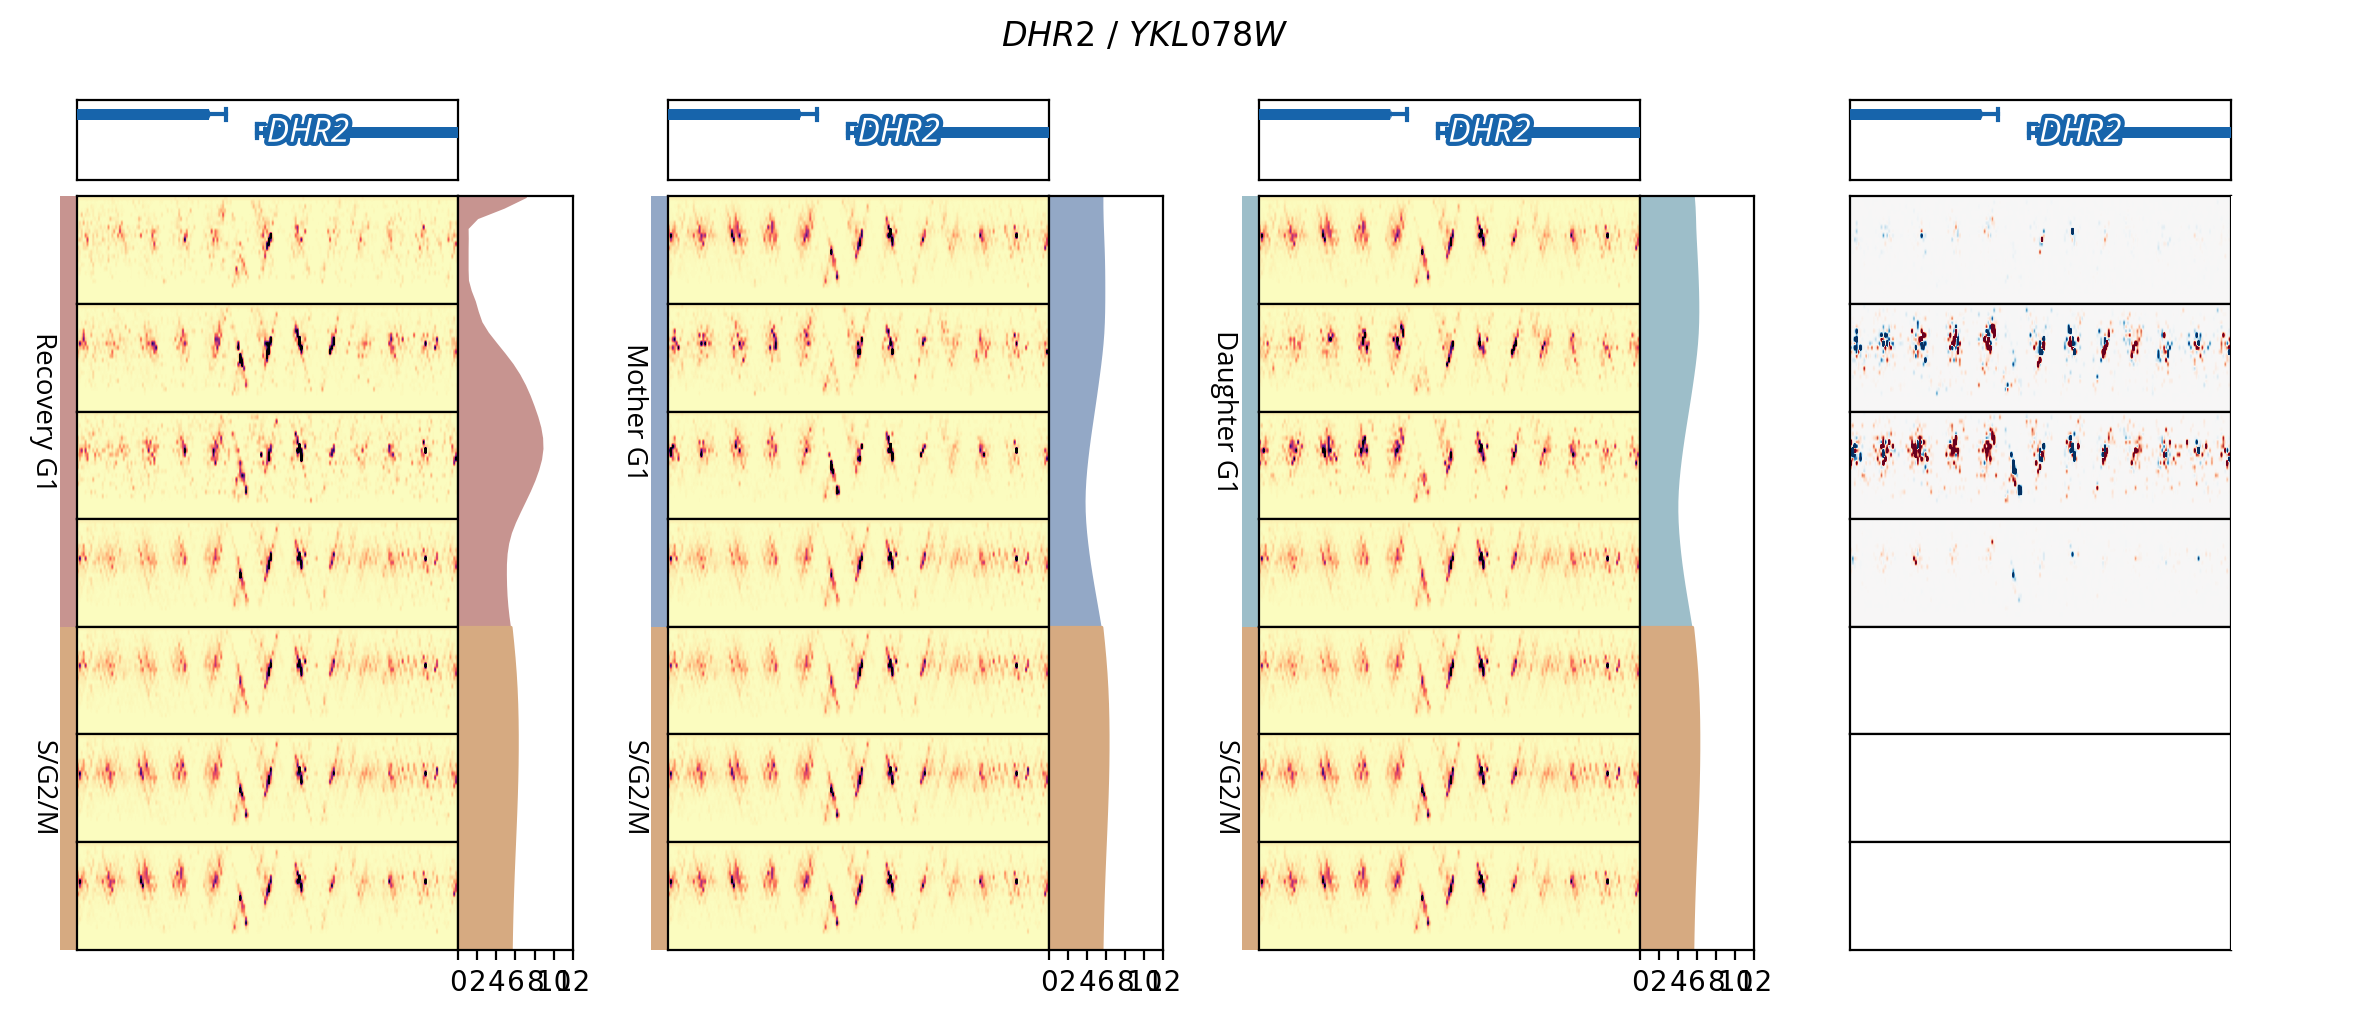

In [664]:
fig = genome_analysis.plot_gene('YKL078W', config1, analysis)

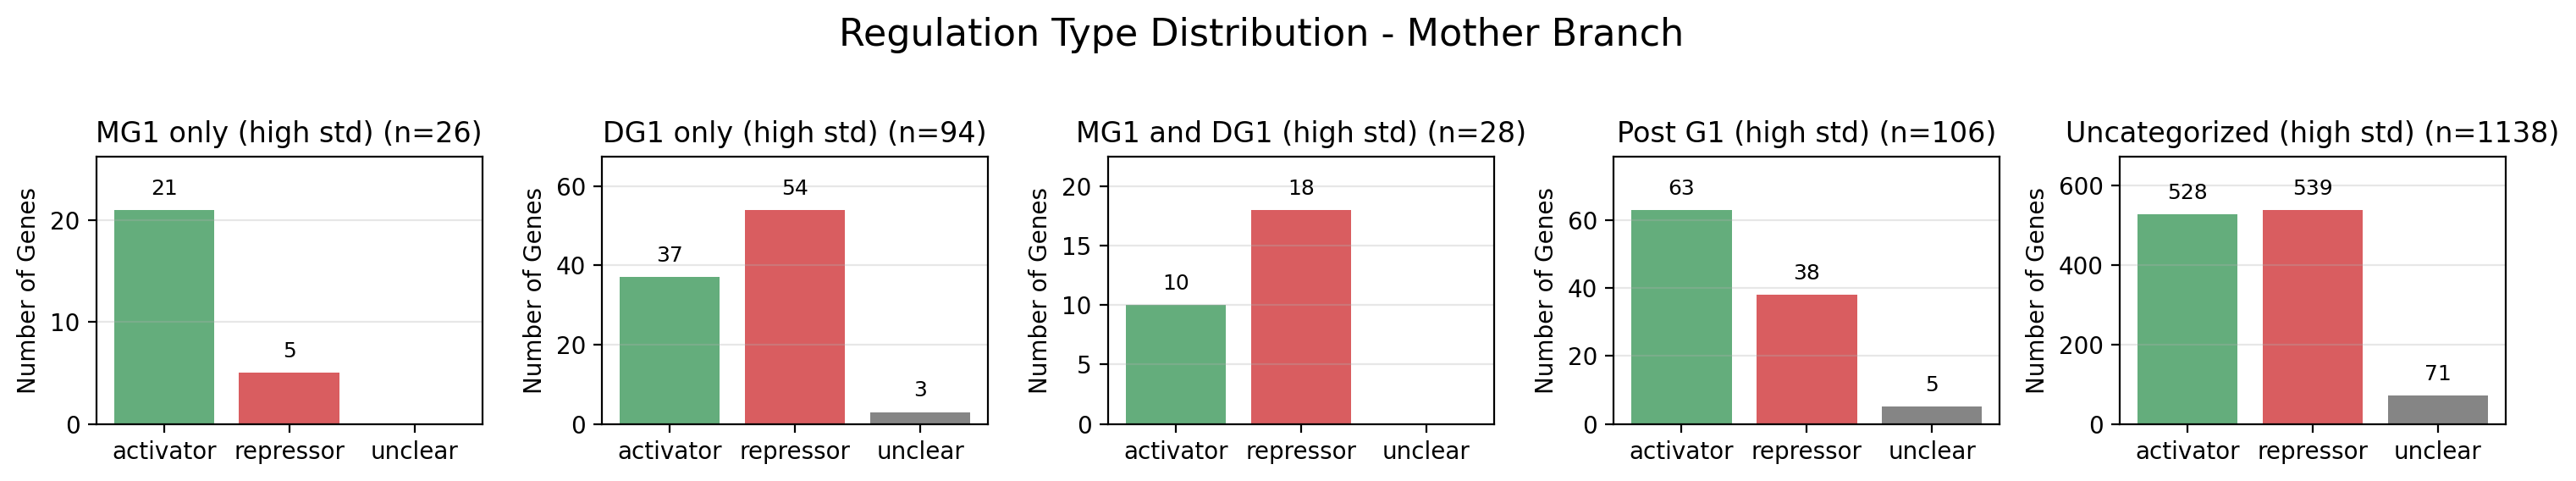

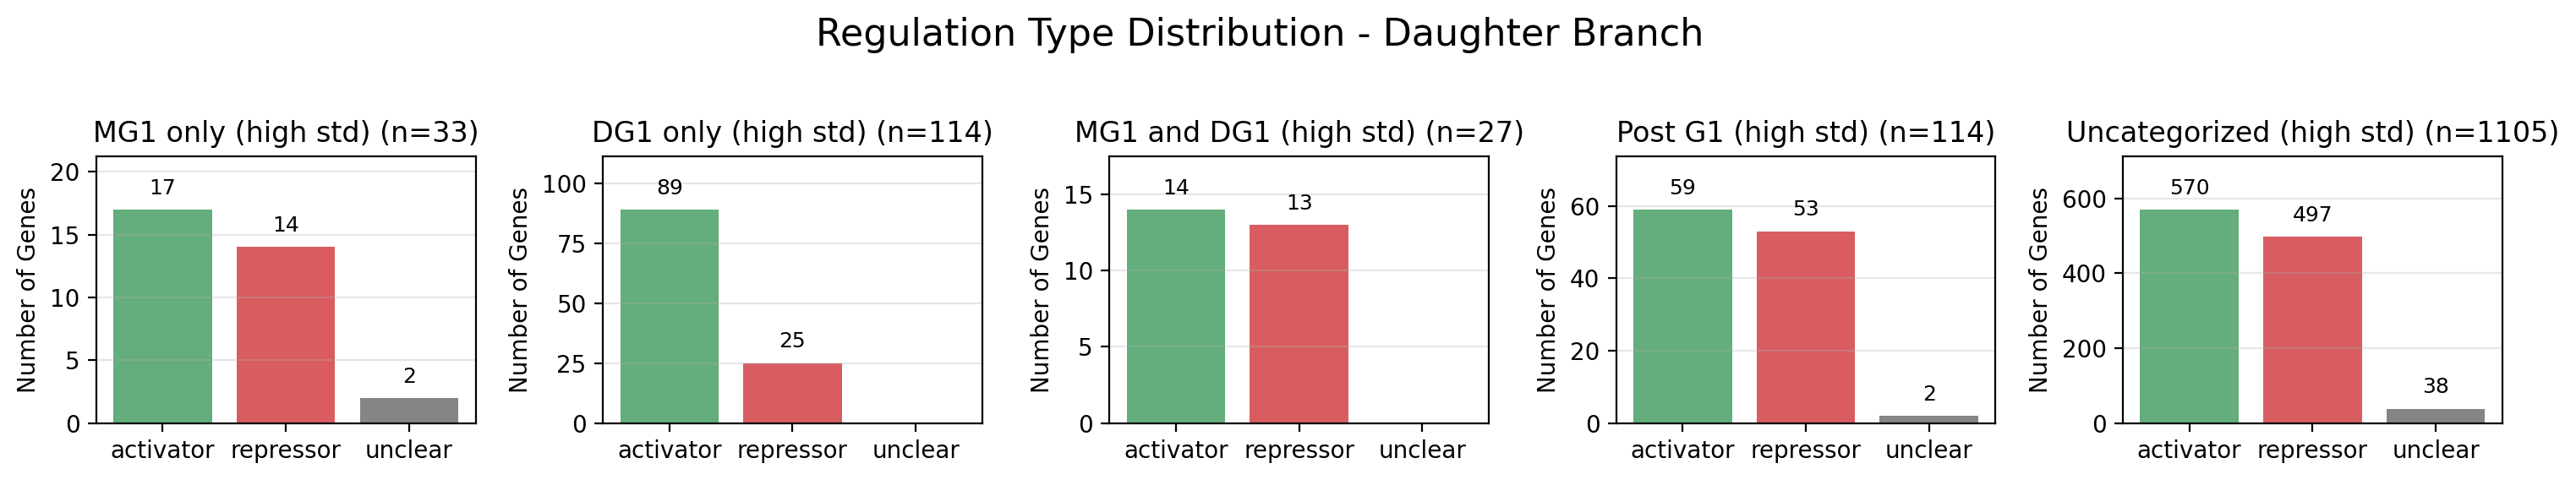

In [667]:
fig = analyzer.plot_regulation_type_bar_counts("mother", m_filtered_gene_subsets)
fig = analyzer.plot_regulation_type_bar_counts("daughter", d_filtered_gene_subsets)

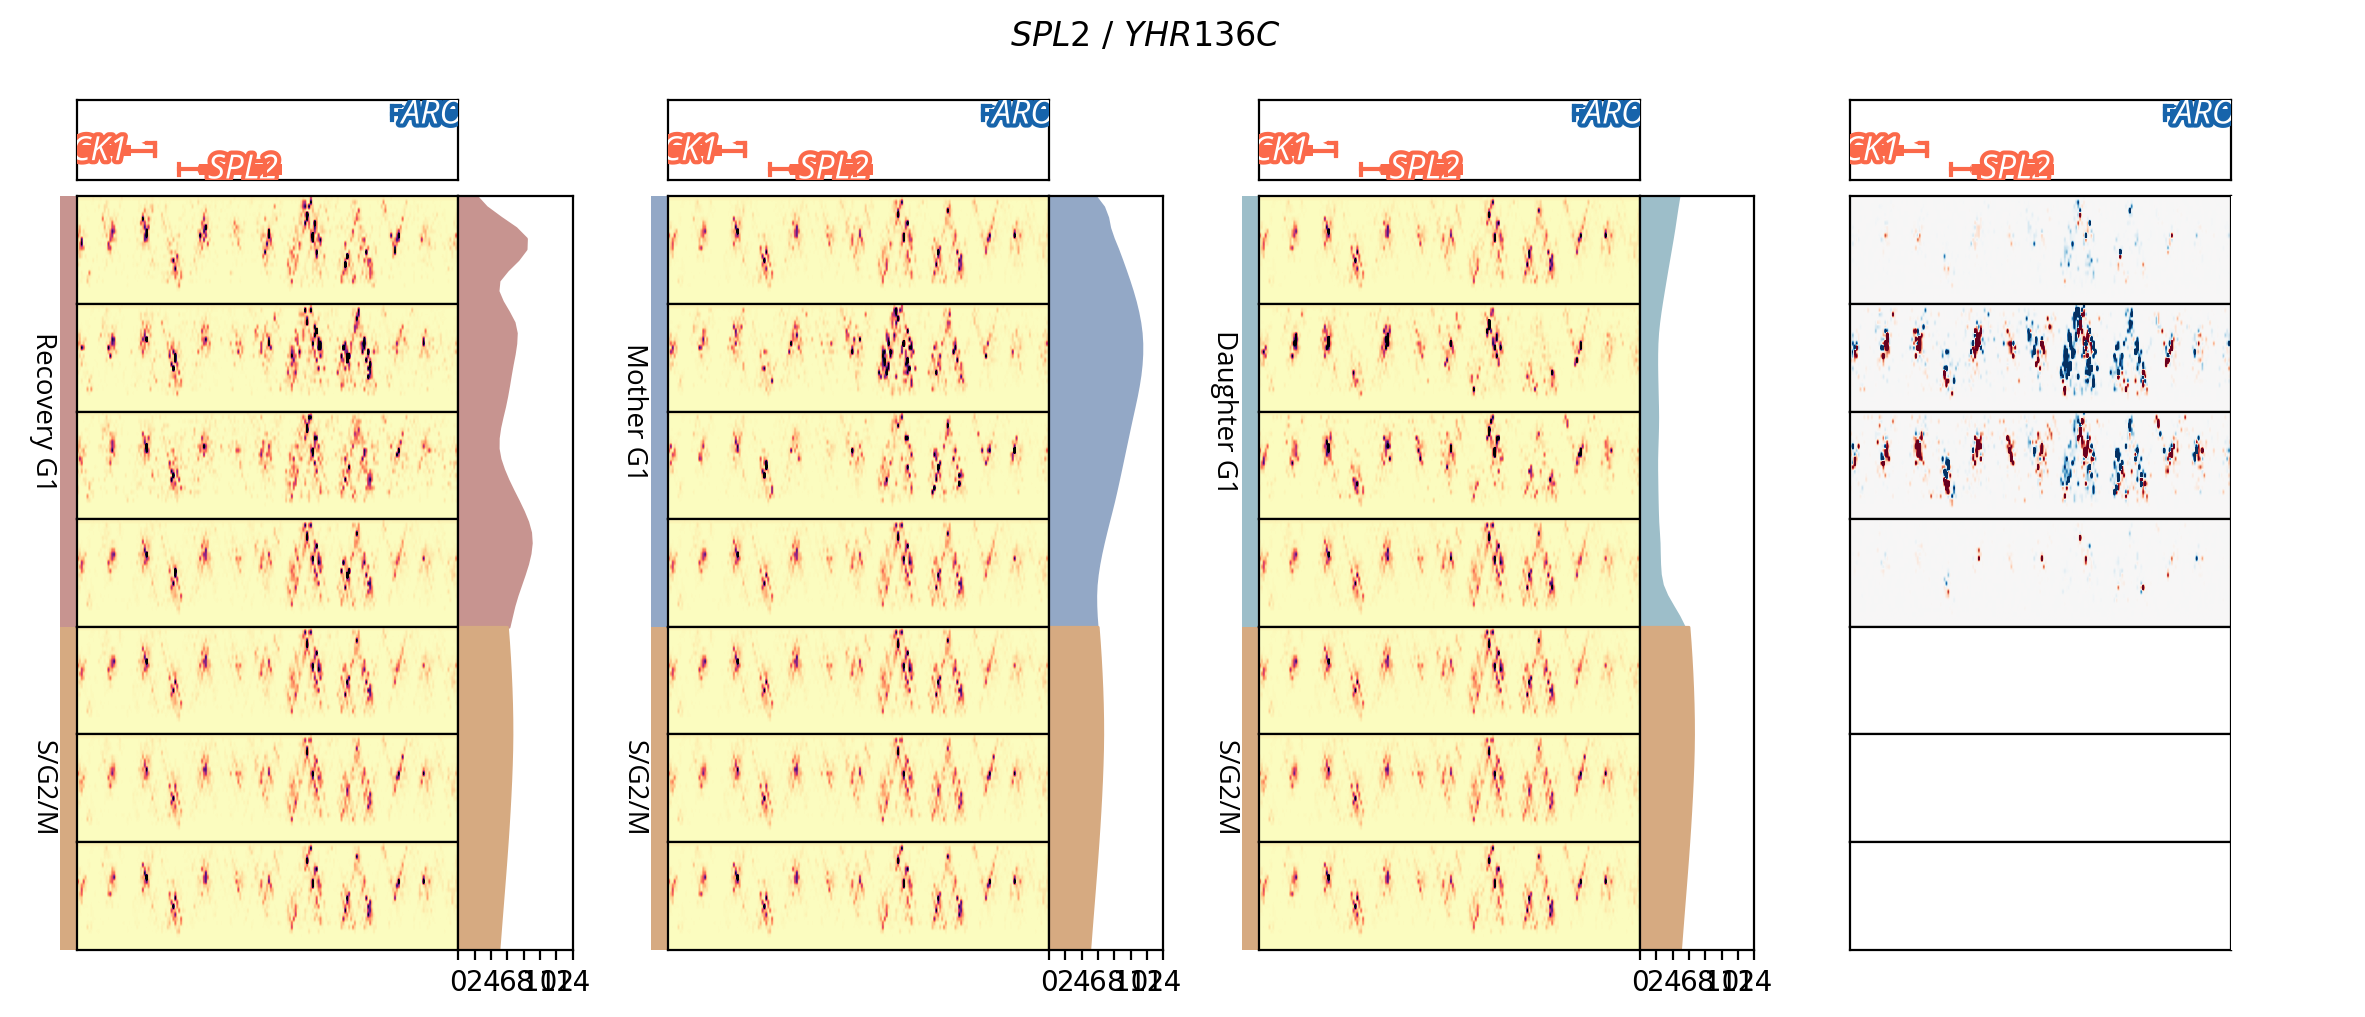

In [671]:
fig = genome_analysis.plot_gene('SPL2', config1, analysis)

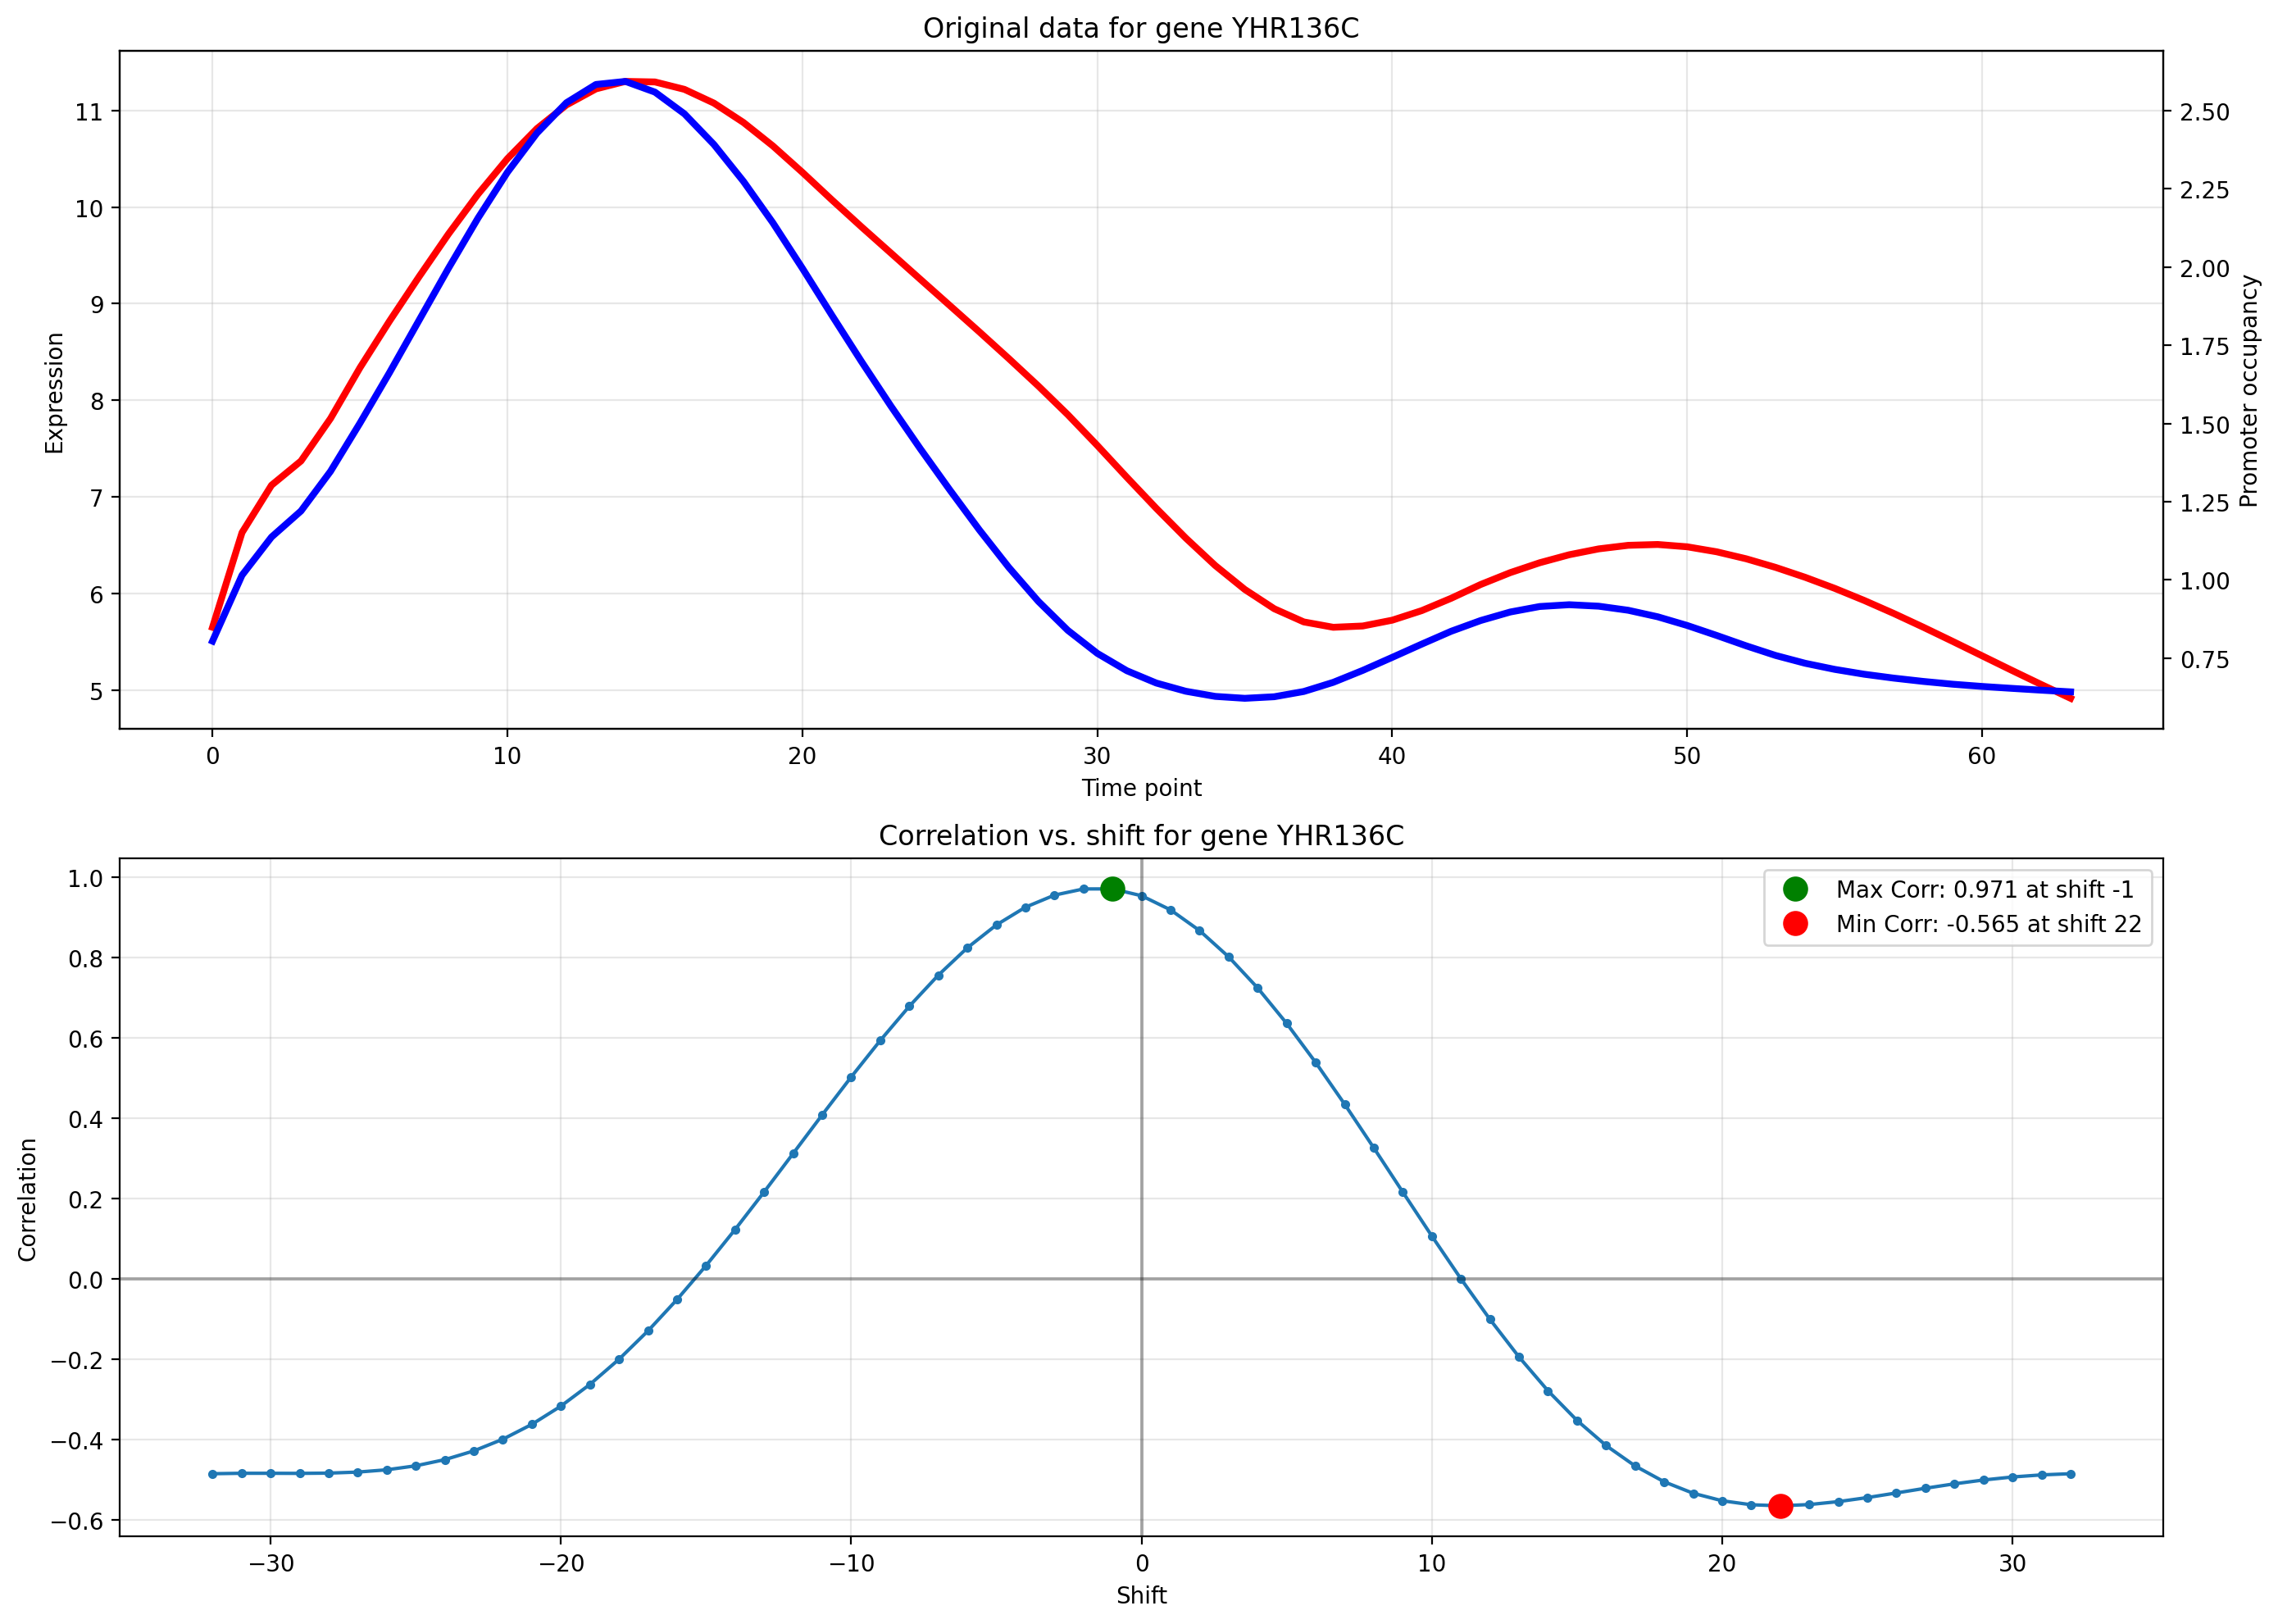

In [673]:
orfname = get_orfname('SPL2')
fig = analyzer.plot_gene_correlation(orfname, branch_name="mother")


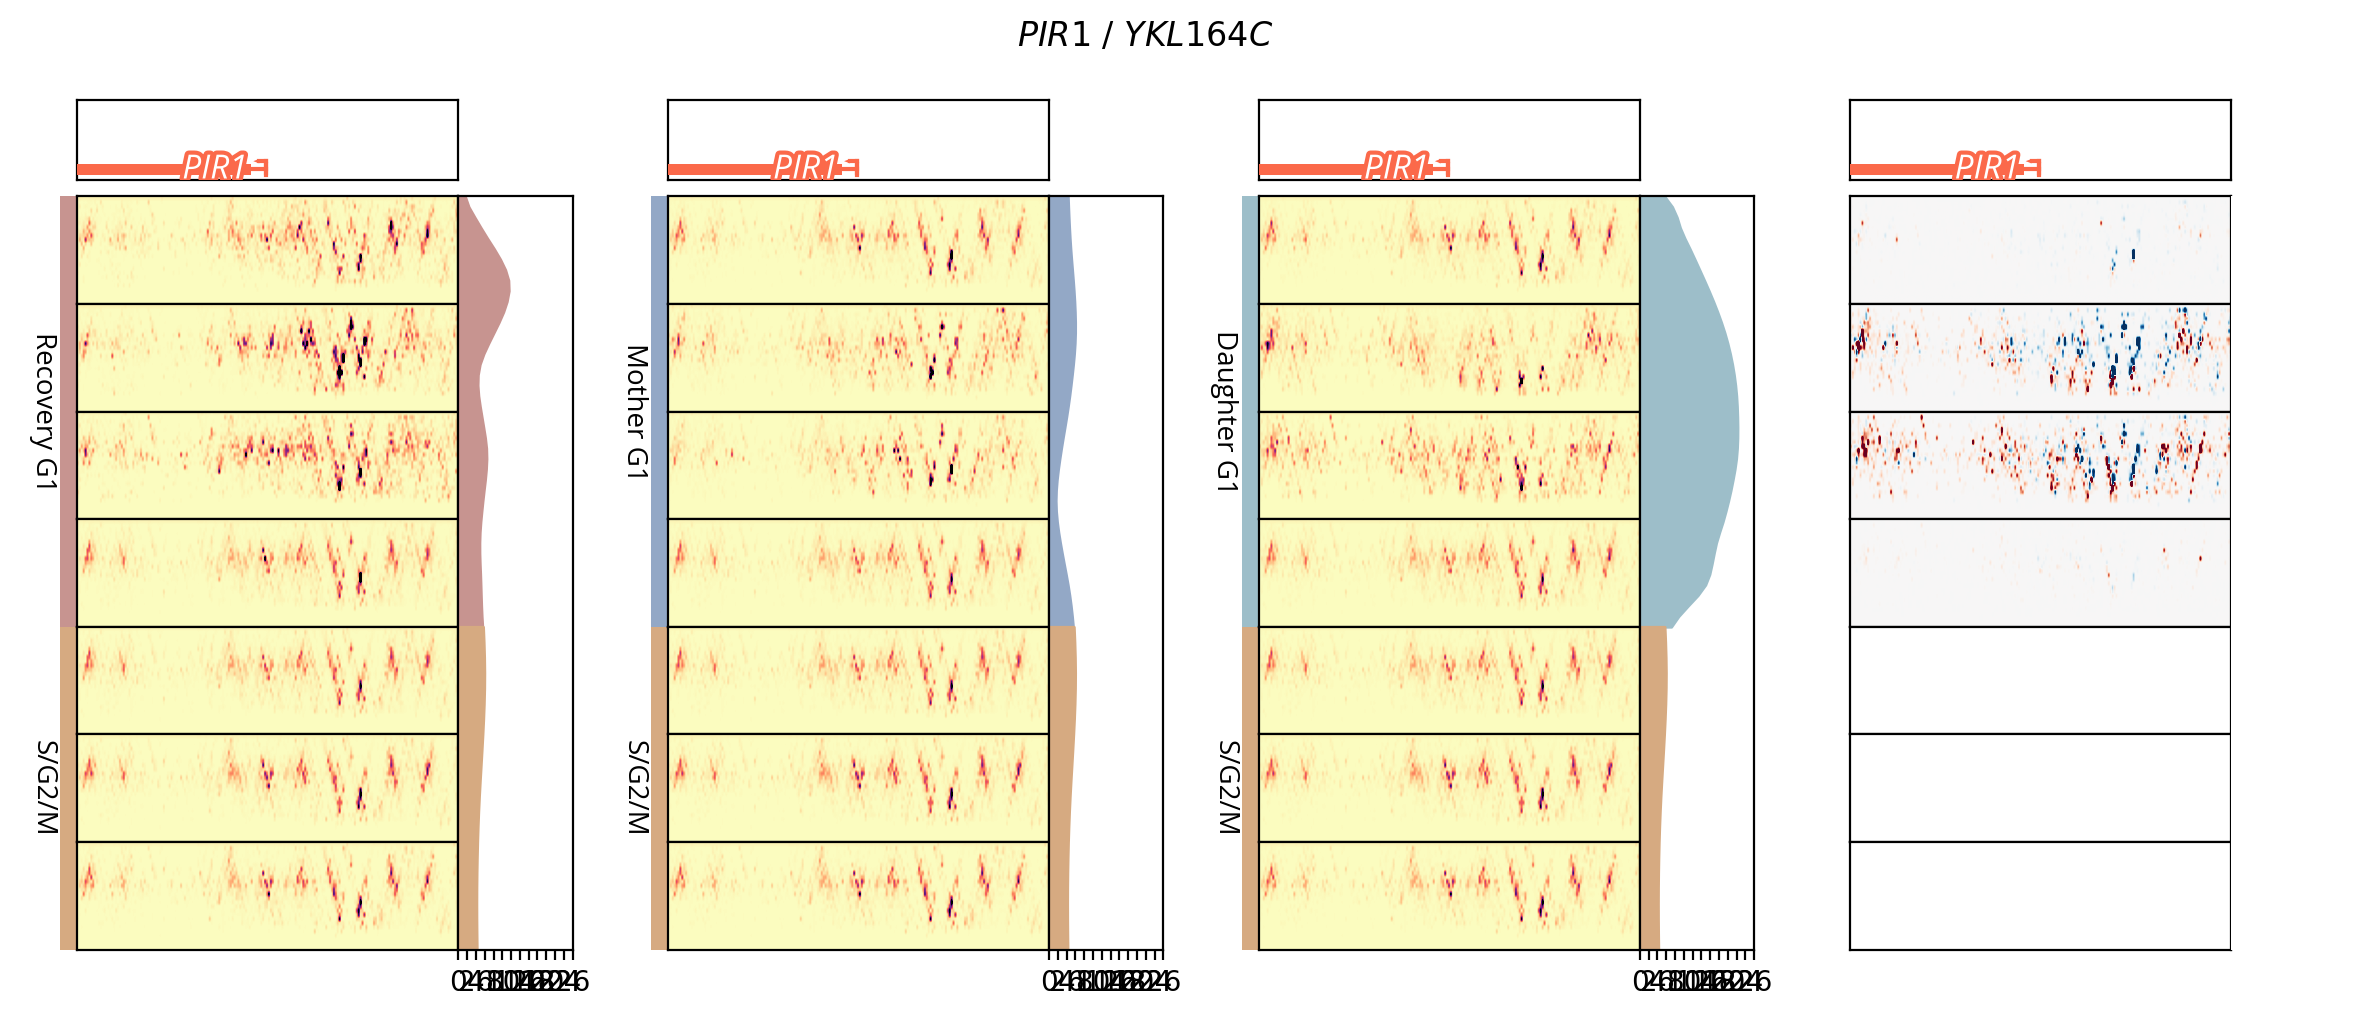

In [668]:
fig = genome_analysis.plot_gene('PIR1', config1, analysis)

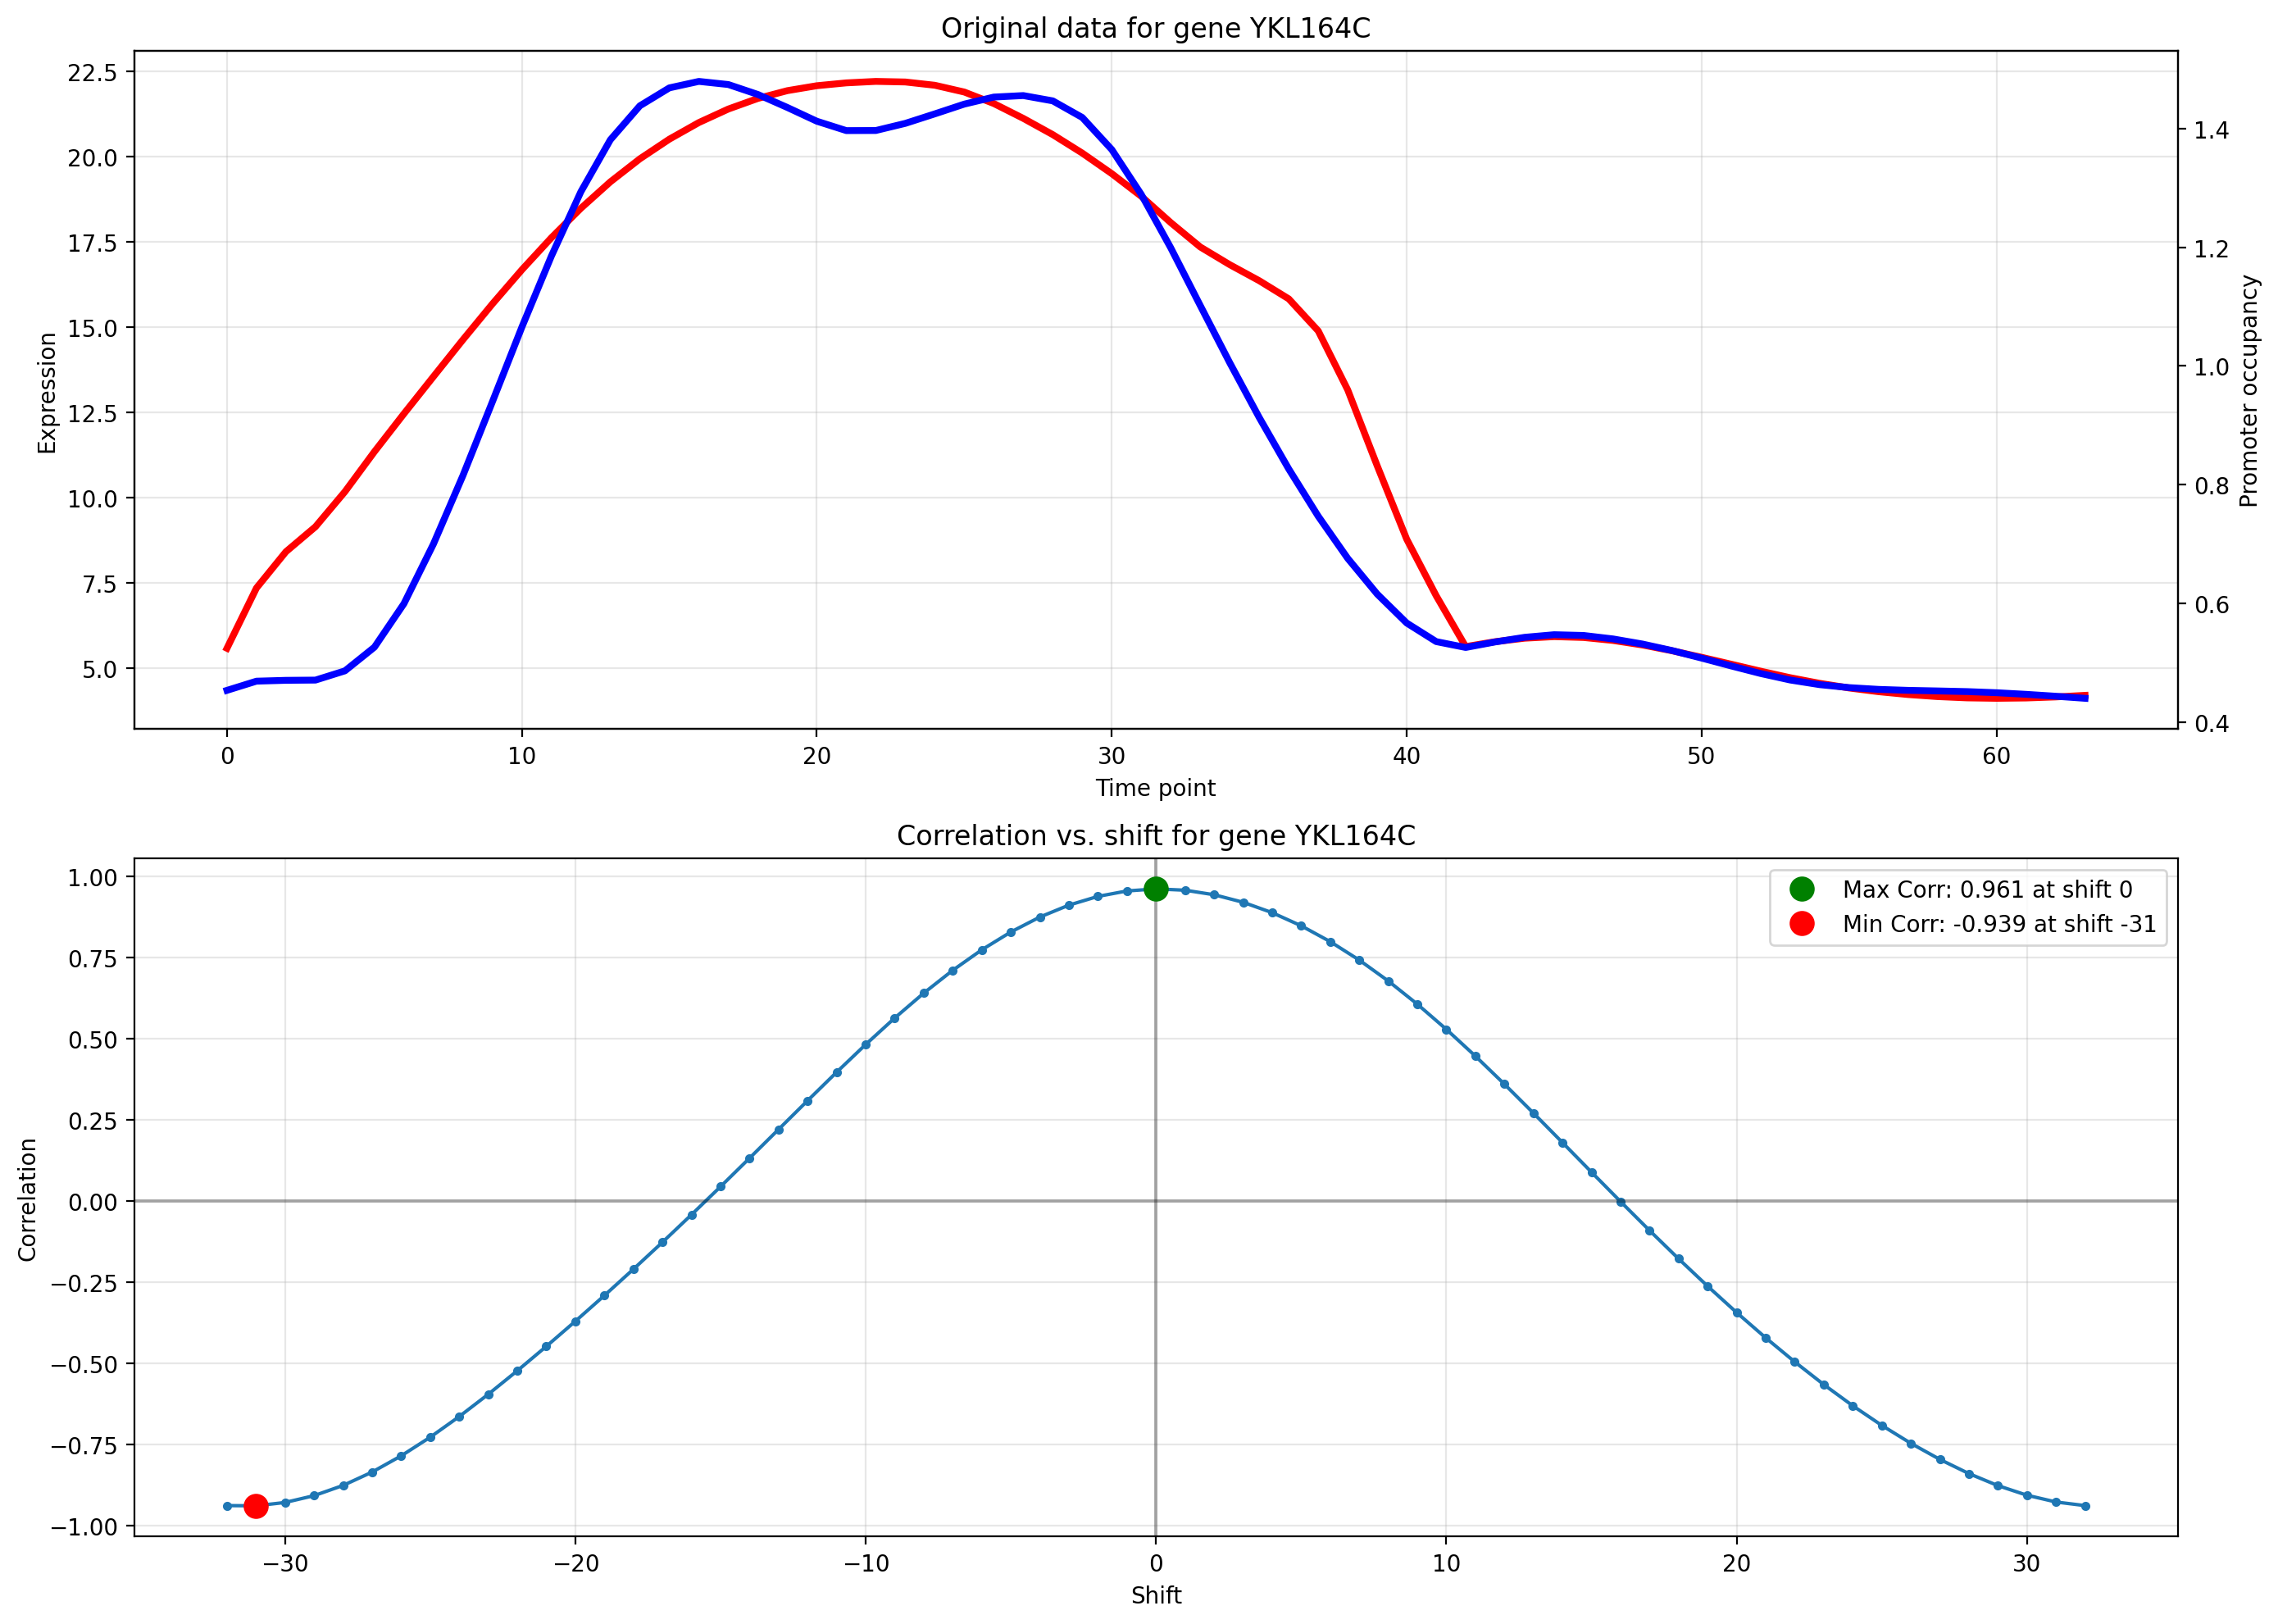

In [670]:
orfname = get_orfname('PIR1')
fig = analyzer.plot_gene_correlation(orfname, branch_name="daughter")
